In [1]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd
import matplotlib

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# split the data into train and test
from sklearn.model_selection import train_test_split

# to build linear regression_model
import statsmodels.api as sm

#to perform LinearRegression
from sklearn.linear_model import LinearRegression

# to check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# scaling
from sklearn.preprocessing import StandardScaler


In [2]:
#Load the dataset
df = pd.read_csv('C:/Users/samhi/Downloads/supply_chain_data.csv')
df

,Ware_house_ID,WH_Manager_ID,Location_type,WH_capacity_size,zone,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,...,electric_supply,dist_from_hub,workers_num,wh_est_year,storage_issue_reported_l3m,temp_reg_mach,approved_wh_govt_certificate,wh_breakdown_l3m,govt_check_l3m,product_wg_ton
0,WH_100000,EID_50000,Urban,Small,West,Zone 6,3,1,2,4651,...,1,91,29.0,NaN,13,0,A,5,15,17115
1,WH_100001,EID_50001,Rural,Large,North,Zone 5,0,0,4,6217,...,1,210,31.0,NaN,4,0,A,3,17,5074
2,WH_100002,EID_50002,Rural,Mid,South,Zone 2,1,0,4,4306,...,0,161,37.0,NaN,17,0,A,6,22,23137
3,WH_100003,EID_50003,Rural,Mid,North,Zone 3,7,4,2,6000,...,0,103,21.0,NaN,17,1,A+,3,27,22115
4,WH_100004,EID_50004,Rural,Large,North,Zone 5,3,1,2,4740,...,1,112,25.0,2009.0,18,0,C,6,24,24071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,WH_124995,EID_74995,Rural,Small,North,Zone 1,3,0,4,5390,...,1,142,34.0,2005.0,22,1,A,2,30,32093
24996,WH_124996,EID_74996,Rural,Mid,West,Zone 2,6,0,4,4490,...,1,130,28.0,2012.0,10,0,B,4,18,12114
24997,WH_124997,EID_74997,Urban,Large,South,Zone 5,7,0,2,5403,...,1,147,NaN,NaN,23,0,B+,5,25,27080
24998,WH_124998,EID_74998,Rural,Small,North,Zone 1,1,0,2,10562,...,1,60,25.0,NaN,18,0,A,6,30,25093


In [3]:
pd.options.display.max_columns = None

In [4]:
df

,Ware_house_ID,WH_Manager_ID,Location_type,WH_capacity_size,zone,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,wh_owner_type,distributor_num,flood_impacted,flood_proof,electric_supply,dist_from_hub,workers_num,wh_est_year,storage_issue_reported_l3m,temp_reg_mach,approved_wh_govt_certificate,wh_breakdown_l3m,govt_check_l3m,product_wg_ton
0,WH_100000,EID_50000,Urban,Small,West,Zone 6,3,1,2,4651,Rented,24,0,1,1,91,29.0,NaN,13,0,A,5,15,17115
1,WH_100001,EID_50001,Rural,Large,North,Zone 5,0,0,4,6217,Company Owned,47,0,0,1,210,31.0,NaN,4,0,A,3,17,5074
2,WH_100002,EID_50002,Rural,Mid,South,Zone 2,1,0,4,4306,Company Owned,64,0,0,0,161,37.0,NaN,17,0,A,6,22,23137
3,WH_100003,EID_50003,Rural,Mid,North,Zone 3,7,4,2,6000,Rented,50,0,0,0,103,21.0,NaN,17,1,A+,3,27,22115
4,WH_100004,EID_50004,Rural,Large,North,Zone 5,3,1,2,4740,Company Owned,42,1,0,1,112,25.0,2009.0,18,0,C,6,24,24071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,WH_124995,EID_74995,Rural,Small,North,Zone 1,3,0,4,5390,Rented,19,0,0,1,142,34.0,2005.0,22,1,A,2,30,32093
24996,WH_124996,EID_74996,Rural,Mid,West,Zone 2,6,0,4,4490,Company Owned,57,0,0,1,130,28.0,2012.0,10,0,B,4,18,12114
24997,WH_124997,EID_74997,Urban,Large,South,Zone 5,7,0,2,5403,Rented,31,1,0,1,147,NaN,NaN,23,0,B+,5,25,27080
24998,WH_124998,EID_74998,Rural,Small,North,Zone 1,1,0,2,10562,Rented,25,0,0,1,60,25.0,NaN,18,0,A,6,30,25093


### EXLPLORATORY DATA ANALYSIS

### 1. Data Collection and Background

The dataset contains historical sales and supply data to determine the optimum quantity of product to ship to each warehouse.

* Ware_house_ID: Product warehouse ID
* WH_Manager_ID: Employee ID of warehouse manager
* Location_type: Location of the warehouse, like in a city or a village
* WH_capacity_size: Storage capacity size of the warehouse
* zone: Zone of the warehouse
* WH_regional_zone: Regional zone of the warehouse under each zone
* num_refill_req_l3m: Number of times refilling has been done in the last 3 months
* transport_issue_l1y: Any transport issue, like an accident or goods stolen, reported in the last year
* Competitor_in_mkt: Number of instant noodles competitors in the market
* retail_shop_num: Number of retail shops that sell the product under the warehouse area
* wh_owner_type: Company owns the warehouse, or they have rented the warehouse
* distributor_num: Number of distributors working between the warehouse and retail shops
* flood_impacted: Warehouse is in the flood-impacted area indicator
* flood_proof: Warehouse is flood-proof. Like storage is at some height, not directly on the ground
* electric_supply: The Warehouse has an electric backup, like a generator, so they can run the warehouse in load shedding
* dist_from_hub: Distance between the warehouse to the production hub in Kms
* workers_num: Number of workers working in the warehouse
* wh_est_year: Warehouse established year
* storage_issue_reported_l3m: Warehouse reported a storage issue to the corporate office in the last 3 months. Like rats, fungus due to moisture, etc.
* temp_reg_mach: Warehouse has a temperature regulating machine indicator
* approved_wh_govt_certificate: What kind of standard certificate has been issued to the warehouse from the government regulatory body
* wh_breakdown_l3m: Number of times the warehouse faced a breakdown in the last 3 months. Like a strike by workers, a flood, or an electrical failure
* govt_check_l3m: Number of times government officers have visited the warehouse to check the quality and expiry of stored food in the last 3 months
* product_wg_ton: Product has been shipped in the last 3 months. Weight is in tons

#### Target variable: product_wg_ton

### 2. Data Overview

In [5]:
#Viewing first 5 rows of the dataset
df.head()

,Ware_house_ID,WH_Manager_ID,Location_type,WH_capacity_size,zone,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,wh_owner_type,distributor_num,flood_impacted,flood_proof,electric_supply,dist_from_hub,workers_num,wh_est_year,storage_issue_reported_l3m,temp_reg_mach,approved_wh_govt_certificate,wh_breakdown_l3m,govt_check_l3m,product_wg_ton
0,WH_100000,EID_50000,Urban,Small,West,Zone 6,3,1,2,4651,Rented,24,0,1,1,91,29.0,NaN,13,0,A,5,15,17115
1,WH_100001,EID_50001,Rural,Large,North,Zone 5,0,0,4,6217,Company Owned,47,0,0,1,210,31.0,NaN,4,0,A,3,17,5074
2,WH_100002,EID_50002,Rural,Mid,South,Zone 2,1,0,4,4306,Company Owned,64,0,0,0,161,37.0,NaN,17,0,A,6,22,23137
3,WH_100003,EID_50003,Rural,Mid,North,Zone 3,7,4,2,6000,Rented,50,0,0,0,103,21.0,NaN,17,1,A+,3,27,22115
4,WH_100004,EID_50004,Rural,Large,North,Zone 5,3,1,2,4740,Company Owned,42,1,0,1,112,25.0,2009.0,18,0,C,6,24,24071


In [6]:
#Viewing last 5 rows of the dataset
df.tail()

,Ware_house_ID,WH_Manager_ID,Location_type,WH_capacity_size,zone,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,wh_owner_type,distributor_num,flood_impacted,flood_proof,electric_supply,dist_from_hub,workers_num,wh_est_year,storage_issue_reported_l3m,temp_reg_mach,approved_wh_govt_certificate,wh_breakdown_l3m,govt_check_l3m,product_wg_ton
24995,WH_124995,EID_74995,Rural,Small,North,Zone 1,3,0,4,5390,Rented,19,0,0,1,142,34.0,2005.0,22,1,A,2,30,32093
24996,WH_124996,EID_74996,Rural,Mid,West,Zone 2,6,0,4,4490,Company Owned,57,0,0,1,130,28.0,2012.0,10,0,B,4,18,12114
24997,WH_124997,EID_74997,Urban,Large,South,Zone 5,7,0,2,5403,Rented,31,1,0,1,147,NaN,NaN,23,0,B+,5,25,27080
24998,WH_124998,EID_74998,Rural,Small,North,Zone 1,1,0,2,10562,Rented,25,0,0,1,60,25.0,NaN,18,0,A,6,30,25093
24999,WH_124999,EID_74999,Rural,Mid,West,Zone 4,8,2,4,5664,Company Owned,21,0,1,1,239,39.0,2019.0,4,0,B+,2,11,5058


In [7]:
# Shape of the dataset
df.shape

(25000, 24)

In [8]:
# Data types of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ware_house_ID                 25000 non-null  object 
 1   WH_Manager_ID                 25000 non-null  object 
 2   Location_type                 25000 non-null  object 
 3   WH_capacity_size              25000 non-null  object 
 4   zone                          25000 non-null  object 
 5   WH_regional_zone              25000 non-null  object 
 6   num_refill_req_l3m            25000 non-null  int64  
 7   transport_issue_l1y           25000 non-null  int64  
 8   Competitor_in_mkt             25000 non-null  int64  
 9   retail_shop_num               25000 non-null  int64  
 10  wh_owner_type                 25000 non-null  object 
 11  distributor_num               25000 non-null  int64  
 12  flood_impacted                25000 non-null  int64  
 13  f

In [9]:
#Checke the shape of the dataset
df.shape

(25000, 24)

In [10]:
# Checking for duplicates
df.duplicated().sum()

0

In [11]:
# Checking for nulls
df.isnull().sum()

Ware_house_ID                       0
WH_Manager_ID                       0
Location_type                       0
WH_capacity_size                    0
zone                                0
WH_regional_zone                    0
num_refill_req_l3m                  0
transport_issue_l1y                 0
Competitor_in_mkt                   0
retail_shop_num                     0
wh_owner_type                       0
distributor_num                     0
flood_impacted                      0
flood_proof                         0
electric_supply                     0
dist_from_hub                       0
workers_num                       990
wh_est_year                     11881
storage_issue_reported_l3m          0
temp_reg_mach                       0
approved_wh_govt_certificate      908
wh_breakdown_l3m                    0
govt_check_l3m                      0
product_wg_ton                      0
dtype: int64

In [12]:
#Percentage of null values
(df.isnull().sum()/len(df))*100

Ware_house_ID                    0.000
WH_Manager_ID                    0.000
Location_type                    0.000
WH_capacity_size                 0.000
zone                             0.000
WH_regional_zone                 0.000
num_refill_req_l3m               0.000
transport_issue_l1y              0.000
Competitor_in_mkt                0.000
retail_shop_num                  0.000
wh_owner_type                    0.000
distributor_num                  0.000
flood_impacted                   0.000
flood_proof                      0.000
electric_supply                  0.000
dist_from_hub                    0.000
workers_num                      3.960
wh_est_year                     47.524
storage_issue_reported_l3m       0.000
temp_reg_mach                    0.000
approved_wh_govt_certificate     3.632
wh_breakdown_l3m                 0.000
govt_check_l3m                   0.000
product_wg_ton                   0.000
dtype: float64

In [13]:
#Statistical summary of dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
num_refill_req_l3m,25000.0,4.089040,2.606612,0.0,2.0,4.0,6.0,8.0
transport_issue_l1y,25000.0,0.773680,1.199449,0.0,0.0,0.0,1.0,5.0
Competitor_in_mkt,25000.0,3.104200,1.141663,0.0,2.0,3.0,4.0,12.0
retail_shop_num,25000.0,4985.711560,1052.825252,1821.0,4313.0,4859.0,5500.0,11008.0
distributor_num,25000.0,42.418120,16.064329,15.0,29.0,42.0,56.0,70.0
flood_impacted,25000.0,0.098160,0.297537,0.0,0.0,0.0,0.0,1.0
flood_proof,25000.0,0.054640,0.227281,0.0,0.0,0.0,0.0,1.0
electric_supply,25000.0,0.656880,0.474761,0.0,0.0,1.0,1.0,1.0
dist_from_hub,25000.0,163.537320,62.718609,55.0,109.0,164.0,218.0,271.0
workers_num,24010.0,28.944398,7.872534,10.0,24.0,28.0,33.0,98.0


In [14]:
#Statistical summary of categorical variables
df.describe(include=['object', 'category']).T

,count,unique,top,freq
Ware_house_ID,25000,25000,WH_100000,1
WH_Manager_ID,25000,25000,EID_50000,1
Location_type,25000,2,Rural,22957
WH_capacity_size,25000,3,Large,10169
zone,25000,4,North,10278
WH_regional_zone,25000,6,Zone 6,8339
wh_owner_type,25000,2,Company Owned,13578
approved_wh_govt_certificate,24092,5,C,5501


In [15]:
#Checking the unique count of each category
for col in df.columns[df.dtypes=='object']:
    print(df[col].value_counts())
    print('-'*30)

Ware_house_ID
WH_100000    1
WH_116650    1
WH_116672    1
WH_116671    1
WH_116670    1
            ..
WH_108331    1
WH_108330    1
WH_108329    1
WH_108328    1
WH_124999    1
Name: count, Length: 25000, dtype: int64
------------------------------
WH_Manager_ID
EID_50000    1
EID_66650    1
EID_66672    1
EID_66671    1
EID_66670    1
            ..
EID_58331    1
EID_58330    1
EID_58329    1
EID_58328    1
EID_74999    1
Name: count, Length: 25000, dtype: int64
------------------------------
Location_type
Rural    22957
Urban     2043
Name: count, dtype: int64
------------------------------
WH_capacity_size
Large    10169
Mid      10020
Small     4811
Name: count, dtype: int64
------------------------------
zone
North    10278
West      7931
South     6362
East       429
Name: count, dtype: int64
------------------------------
WH_regional_zone
Zone 6    8339
Zone 5    4587
Zone 4    4176
Zone 2    2963
Zone 3    2881
Zone 1    2054
Name: count, dtype: int64
-----------------------

### EXPLORATORY DATA ANALYSIS

In [16]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [17]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        hue=feature,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

### 3. Univariate Analysis

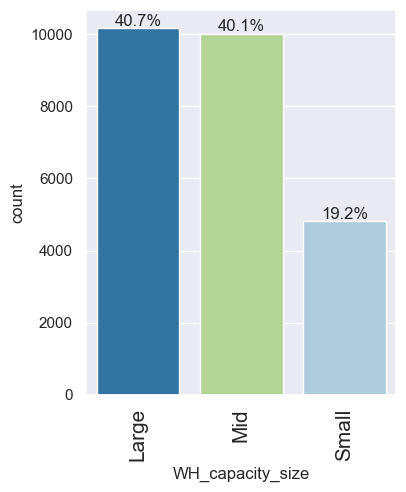

In [18]:
labeled_barplot(df, 'WH_capacity_size', perc=True)

Observations:
* Large and Mid warehouses are balanced between 40.7% to 40.1%.
* Small warehouses account for a smaller portion with 19.2% of the total warehouse network.

Insights:
* The company seems to operate primarily through mid and large capacity storage facilities.
* Large and medium warehouses likely serve high demand markets.
* Smaller warehouses may function as low demand areas.

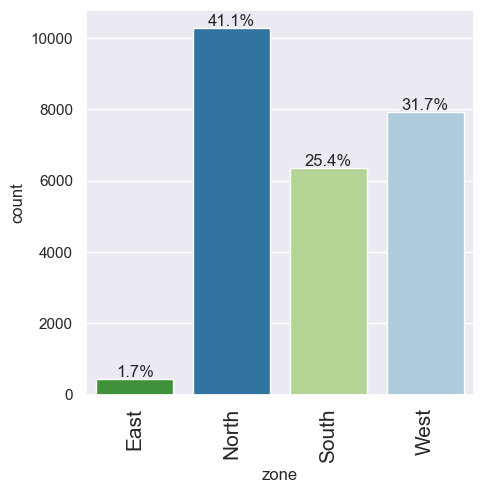

In [19]:
labeled_barplot(df, 'zone', perc=True)

Observations:
* Warehouses are unevenly distributed across North, South, East and West zones.
  * North - 41.1%
  * West - 31.7%
  * South - 25.4%
  * East - 1.7%Ea
* North zone contains the highest concentration of warehouses.
* East zone has a very small percentage compared to others region.

Insights:
* Most of the warehouses are located in North, West and South region.
* The high concentration in these 3 zones may indicate large market demand and high retail density.
* The lower representation in East zone may indicate smaller customer base, limited operations, etc.

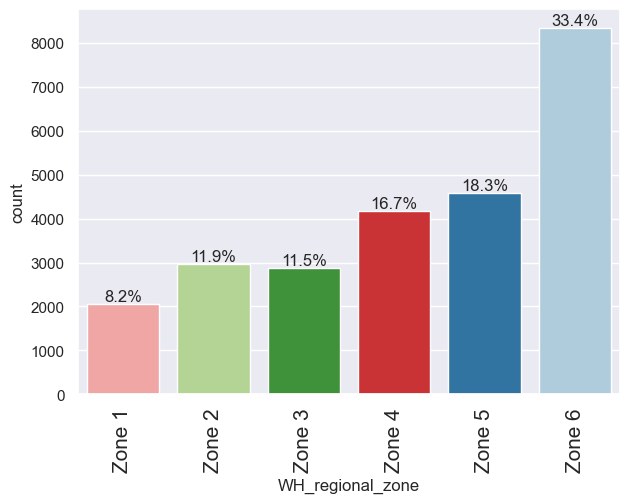

In [20]:
labeled_barplot(df, 'WH_regional_zone', perc=True)

Observations:
* Warehouses are distributed across 6 regions:
  * Zone 1 - 8.2%
  * Zone 2 - 11.9%
  * Zone 3 - 11.5%
  * Zone 4 - 16.7%
  * Zone 5 - 18.3%
  * Zone 6 - 33.4%
* Zone 6 has the highest frequency of warehouses.
* Zone 1, 2, 3 have comparitively lower frequency.

Insights:
* Zone 6 may indicate high market demand, strong retail presence and operational activity.
* Zones with lower percentages may have lower demands or may be developing markets.

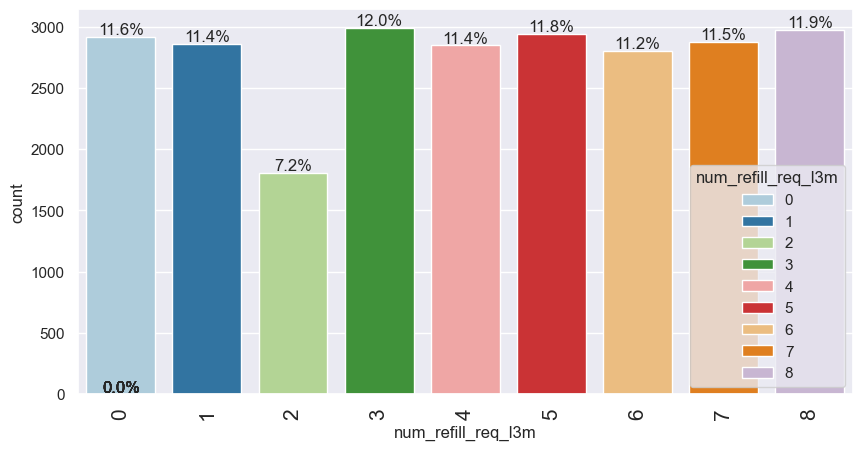

In [21]:
labeled_barplot(df, 'num_refill_req_l3m', perc=True)

Observation:
* The variable ranges from 0 to 8 refill requests. Most of them have equal distributions (~11-12%).
* Most of the warehouses require regular refilling indicating steady demand across regions.
* Only 11.6% of the warehouses have reported 0 refills in the past 3 months.
* There is a dip at 2 refills indicating moderate demand zone.
* Warehouses with 5-8 refills may indicate high demand zones and faster moving inventory hubs.

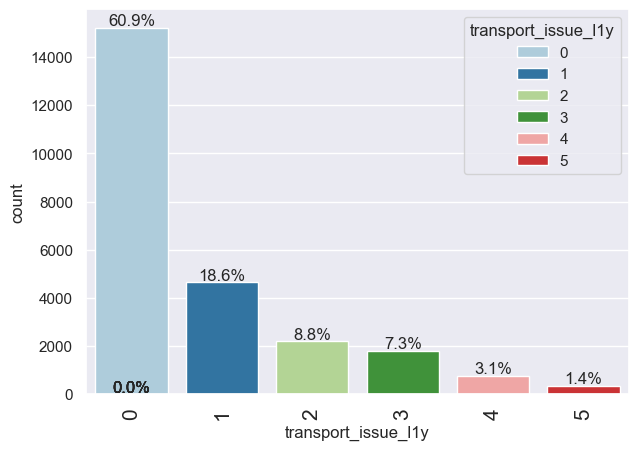

In [22]:
labeled_barplot(df, 'transport_issue_l1y', perc=True)

Observations:
* The distribution is highly right skewed with most warehouses experiencing minimal transportation issues. 
* Around 70% of the warehouses have reported 0 transport issues in the last year.
* 18.6% have experienced 1 transport issue.
* Very few warehouses have experienced more than 3 issues
  * 3 issues - 7.3%
  * 4 issues - 3.1%
  * 5 issues - 1.4%

Insights:
* Most warehouses seem to have efficient transportation system.
* A smaller number of warehouses faces regular issues indication poor road infrastructure, remote areas which may lead to delays in deliveries, increase in operational costs. They can have different routes or backup transportations.

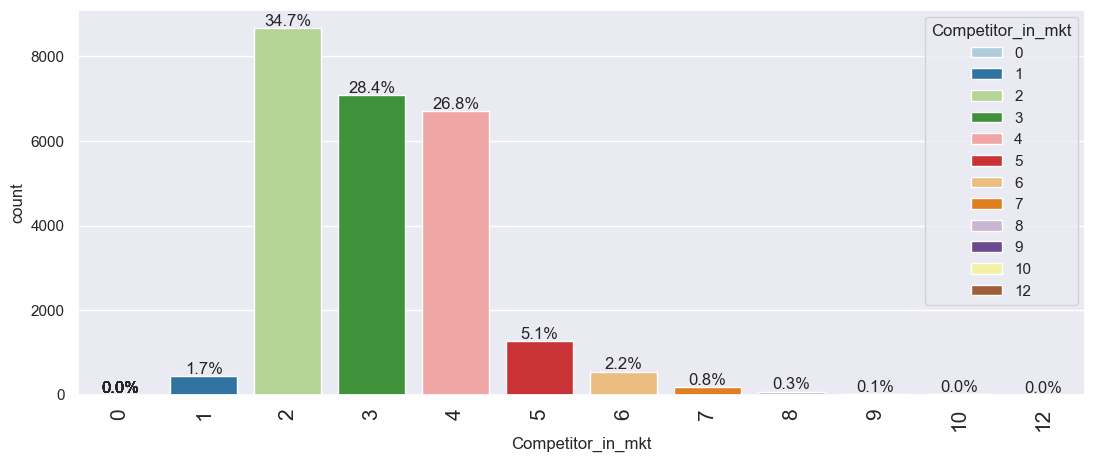

In [23]:
labeled_barplot(df, 'Competitor_in_mkt', perc=True)

Observations:
* Most of the markets have moderate level of competitors.
  * 2 competitors - 34.7%
  * 3 competitors - 28.4%
  * 4 competitors - 26.8%
* Around 1.7% have 1 and below competitors.
* Very few regions have extremely high competitors (6+)

Insights:
* 2-4 competitors suggests a healthy market demand and an active FMCG competition.
* Markets with more competitors may require more strong marketing & better pricing strategies.

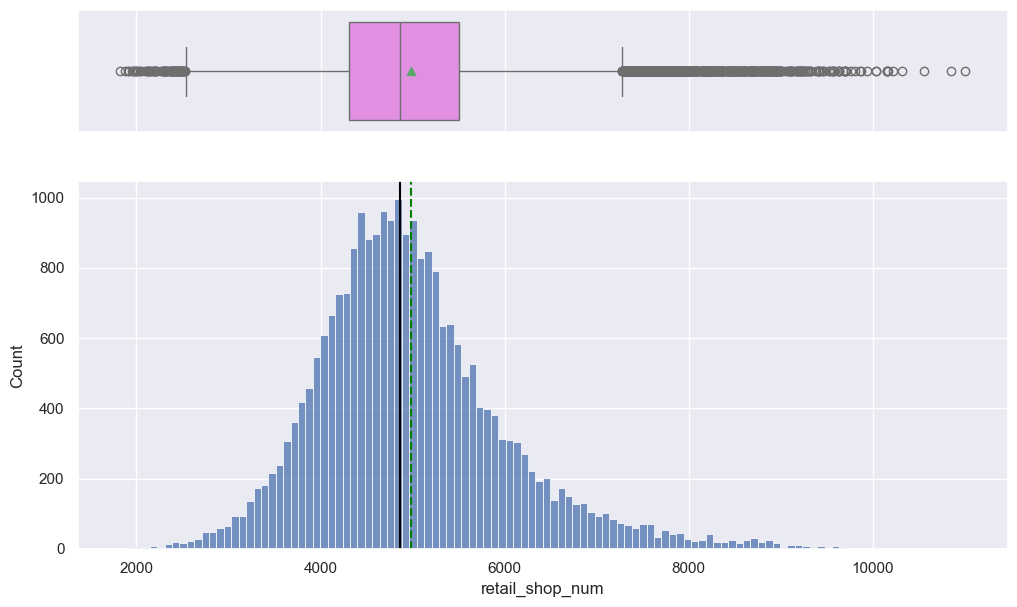

In [24]:
histogram_boxplot(df, 'retail_shop_num')

In [25]:
df['retail_shop_num'].describe()

count    25000.000000
mean      4985.711560
std       1052.825252
min       1821.000000
25%       4313.000000
50%       4859.000000
75%       5500.000000
max      11008.000000
Name: retail_shop_num, dtype: float64

Observations:
* The distribution is slightly skewed to the right.
* Most warehouses have 4000-5500 retail shops.
* Few outliers are seen below 3000 and high value outlier are present exceeding 10000.
* The mean and median are almost close, indicating moderate skewness.

Insights:
* Regions with large number of retail shops may indicate densely populated areas with high demand. They may require higher inventory allocation, faster replenishment cycles and stronger distributor networks.
* Regions with smaller retails may indicate rural or low demand areas.
* The wide variation suggests that the company operates in both urban and rural areas.

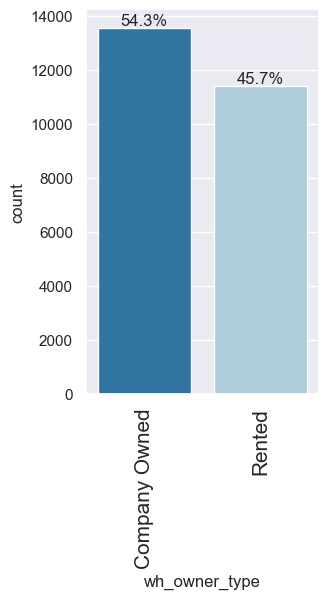

In [26]:
labeled_barplot(df, 'wh_owner_type', perc=True)

Observations:
* Warehouses are almost evenly divided between Company Owned and Rented:
  * Company Owned - 54.3%
  * Rented - 45.7%
* Company owned warehouses is slightly more than Rented facilities.

Insights:
* The distribution indicates a balanced mix of owned and leased facilities.
* Company owned warehouses may have better operational control and better customization.
* Rented warehouses may help the company to reduce initial infrastructure investment.

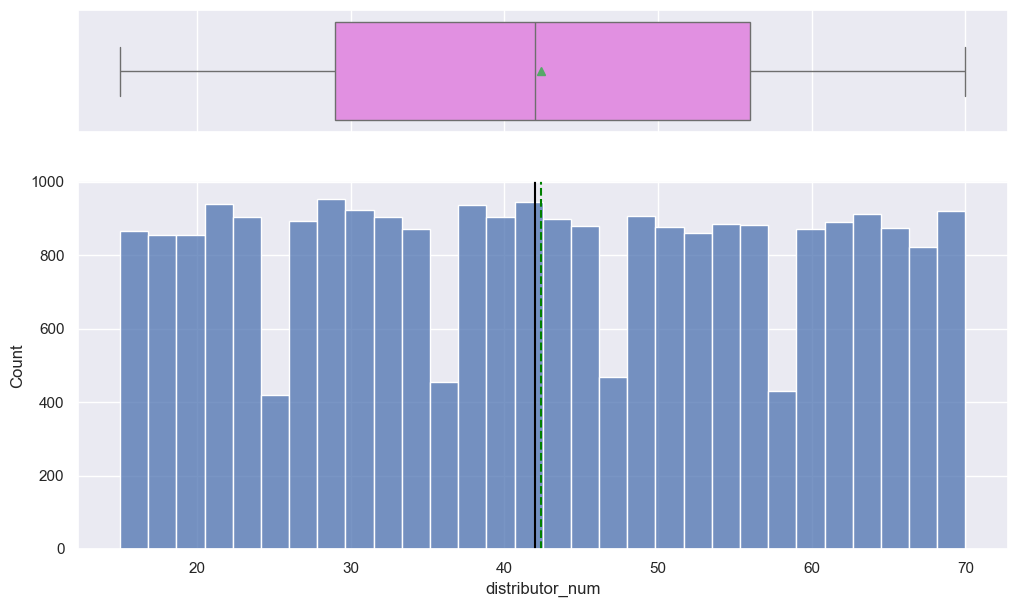

In [27]:
histogram_boxplot(df, 'distributor_num')

In [28]:
df['distributor_num'].describe()

count    25000.000000
mean        42.418120
std         16.064329
min         15.000000
25%         29.000000
50%         42.000000
75%         56.000000
max         70.000000
Name: distributor_num, dtype: float64

Observations:
* The distribution seems uniform across the range 15-70.
* The mean and median are almost identical indicating a balanced distribution.
* No outliers or major skewness present.

Insights:
* The company maintains a fair number of distributors working between the warehouse and retail shops.
* Higher distributor count may support wider market coverage, reduce delays etc.
* Lower distributor count may indicate smaller market region.
* Balanced distributor suggests a stable logistics planning and standardized supply chain operations.

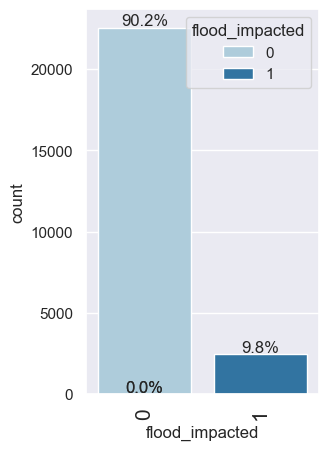

In [29]:
labeled_barplot(df, 'flood_impacted', perc=True)

Observations:
* 9.8% of the warehouses are located in the flood impacted region.
* 90.2% of the warehouses are not flood impacted.

Insights:
* Majority of the warehouse operates in a low-risk regions. 
* A small set of warehouses are vulnerable to inventory damage, delays and disruption in workflow. This may lead to increase in operational cost, logistics  uncertainty.
* These warehouses may require additional stocks, a recovery plan, infrastructure reinforcement.

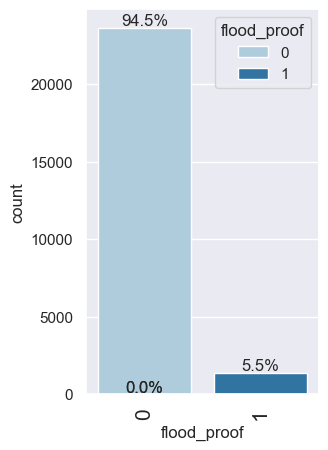

In [30]:
labeled_barplot(df, 'flood_proof', perc=True)

Observations:
* 94.5% of the warehouses are not flood proof. These may be non-flood-impacted zones.
* The other 5.5% are flood proof. These may be the ones that are in the flood-impacted zones.

Insights:
* We see 9.8% of the warehouses are located in the flood impacted region. But only 5.5% are flood proof.
* Limited adoption of flood-proof infrastructure could suggest non risk zones, cost saving decisions.
* Warehouses with flood proof infrastructure could be located in high-risk zones, designed for safer inventory storage.

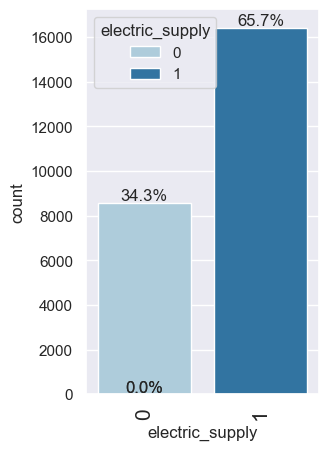

In [31]:
labeled_barplot(df, 'electric_supply', perc=True)

Observations:
* 65.7% of the warehouses have electric backup supply.
* 34.5% of the warehouses lack electric backup supply.

Insights:
* Majority of the warehouses are equipped with power support systems where as a significant portion still operates with a backup power supply.
* Warehouses with electric supply are likely to experience smooth operations. Its important for temperature regulated storage, maintaining the product quality during power outages.
* Warehouses lacking backup power may face operational interruptions, inventory spoilage risks, reduce in operational efficiency.

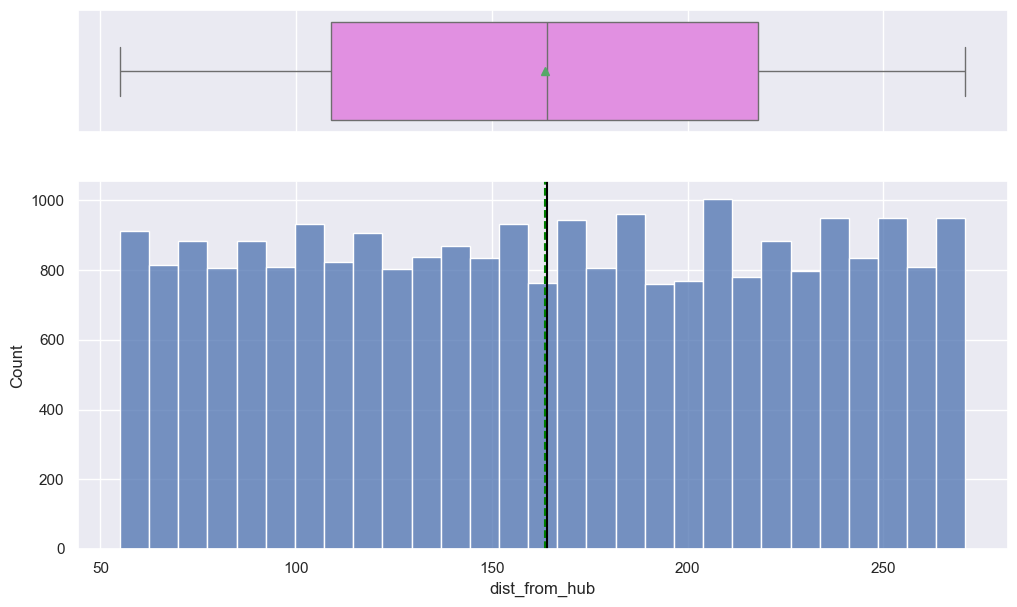

In [32]:
histogram_boxplot(df, 'dist_from_hub')

In [33]:
df['dist_from_hub'].describe()

count    25000.000000
mean       163.537320
std         62.718609
min         55.000000
25%        109.000000
50%        164.000000
75%        218.000000
max        271.000000
Name: dist_from_hub, dtype: float64

Observations:
* The distribution is uniform across the range 55 to 270.
* The histogram shows no skewness or clustering.
* The boxplot shows no outliers.
* Mean and median are almost equal indicating a balanced distribution.

Insights:
* Warehouses are evenly distributed at both short and long distances from the hub.
* It seems like the company maintains a well-planned logistics infrastructure.

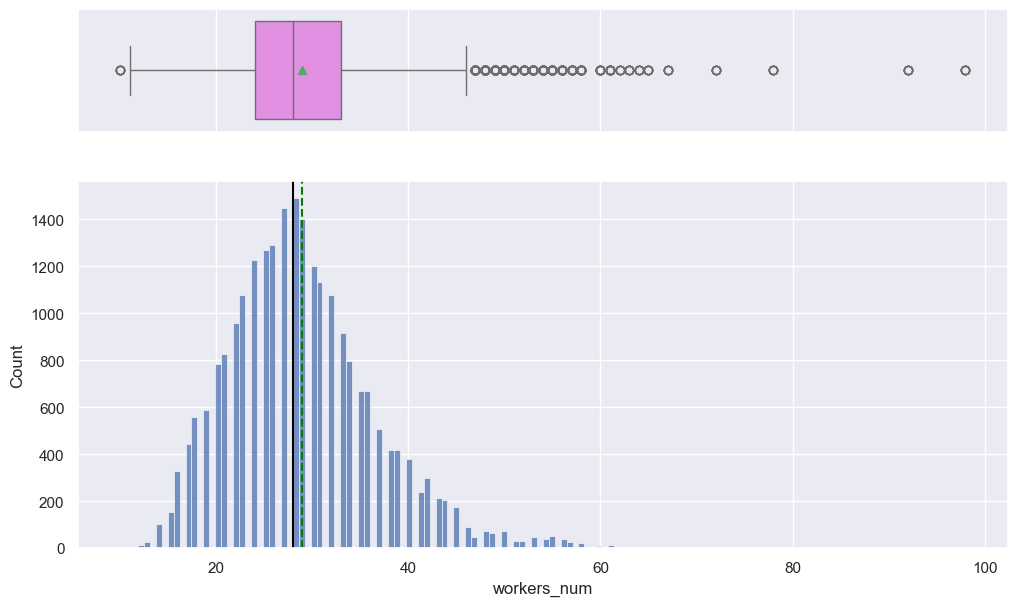

In [34]:
histogram_boxplot(df, 'workers_num')

In [35]:
df['workers_num'].describe()

count    24010.000000
mean        28.944398
std          7.872534
min         10.000000
25%         24.000000
50%         28.000000
75%         33.000000
max         98.000000
Name: workers_num, dtype: float64

Observations:
* The distribution is right skewed.
* Most warehouses employ approx. 20 to 25 workers.
* Many warehouses have very large workforce size, extending up to nearly 100 workers.
* There are few high value outliers.

Insights:
* Many warehouses tend to operate with moderate workforce.
* Warehouses with high workers may indicate high demand centres, large capacity warehouses. They support faster inventory movement, increase in operational efficiency.
* Smaller workforce may indicate low demand regions and smaller storage facilities.

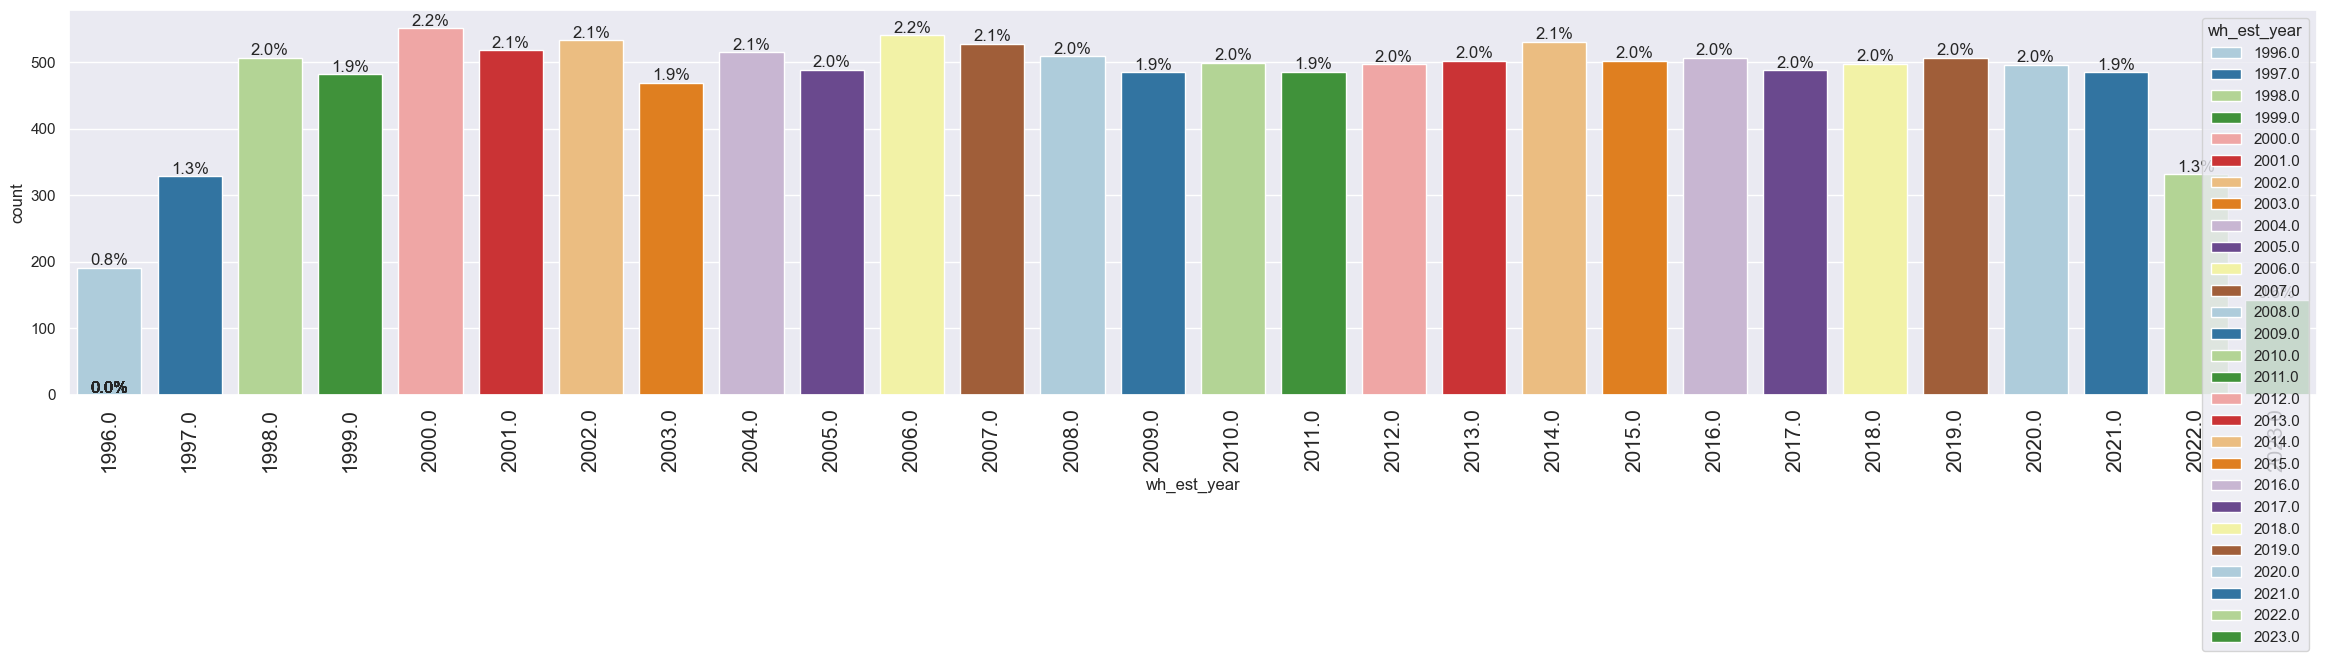

In [36]:
labeled_barplot(df, 'wh_est_year', perc=True)

Observations:
* Warehouses were established between 1996 to 2022.
* The distribution uniform across the years.
* Most of the establishment years contribute 1.7% to 2.2% of the total warehouses.
* Early years like 1996-1997 shows very few warehouses.

Insights:
* The company seem to have expanded warehouse infrastructure steadily over time.
* Older warehouses may represent regions with long term demand, mature distribution centres, established operational hubs.
* Newly established warehouses may indicate market expansion, scaling of suppy chain operations and penetrating into long term demands.
* The balanced establishment distribution suggests a continuous operational growth of the company.

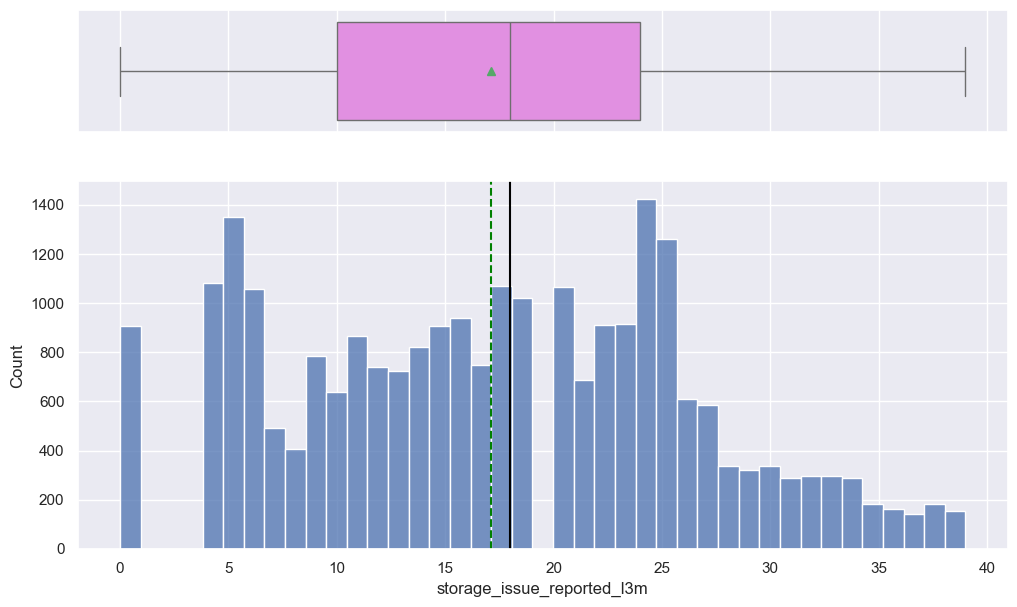

In [37]:
histogram_boxplot(df, 'storage_issue_reported_l3m')

In [38]:
df['storage_issue_reported_l3m'].describe()

count    25000.000000
mean        17.130440
std          9.161108
min          0.000000
25%         10.000000
50%         18.000000
75%         24.000000
max         39.000000
Name: storage_issue_reported_l3m, dtype: float64

Observations:
* The distribution is almost uniform. The values ranges from 0 to 39.
* Most of the warehouses have reported storage issues between 10 and 25 times in the last 3 months.
* The mean and median are relatively close, indicating moderate skewness.
* The boxplot shows no outliers and a wide spread in storage issue frequency.

Insights:
* Warehouses with more issue count may indicate overcrowded storage facilities, poor storage practices, limited infrastructure that might lead to wastage of products, increase in operational costs.
* Warehouses with lower issues likely have better storage facilities, stable inventory turnover.

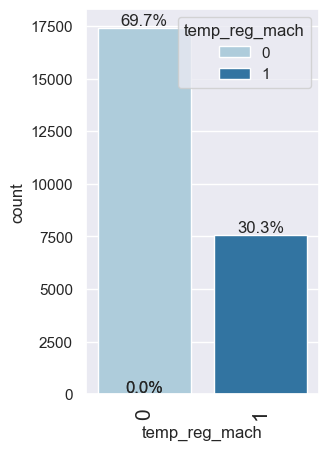

In [39]:
labeled_barplot(df, 'temp_reg_mach', perc=True)

Observations:
* Around 69.7% of the warehouses do not have temperature regulating machines.
* Only 30.3% of the warehouses are equipped with temperature regulating machines.

Insights:
* Majority of the warehouses rely on standard storage conditions without temperature regulating machines.
* Warehouses with temperature regulating machines likely have better preservation of products, better storage quality with reduced the spoilage risk. These warehouses may be premium infrastructure facilities or high-volume warehouses.
* Warehouses with temperature regulating machines may indicate cost consideration towards warehouses that doesn't require advance storage facilities.

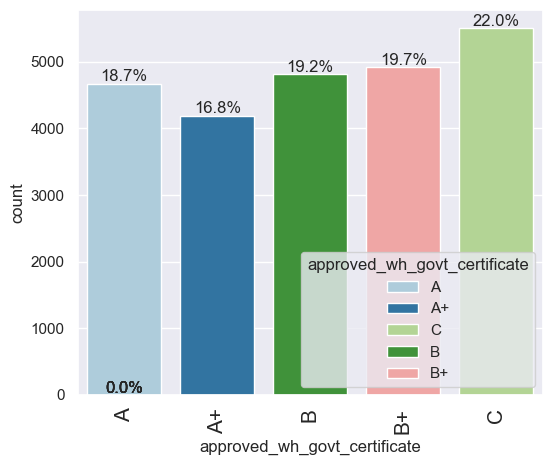

In [40]:
labeled_barplot(df, 'approved_wh_govt_certificate', perc=True)

Observations:
* The distribution is almost balanced between A and C.
  * A (18.7%)
  * A+ (16.8%)
  * B (19.2%)
  * B+ (19.2%)
  * C (22%)
* C has the highest while A+ gets the lowest.

Insights:
* A, A+ certification may indicate better storage facilities, increase in operational efficiency, stronger quality control.
* Lower certifications like B, B+ or C may indicated limited storage, not so stable maintenance.

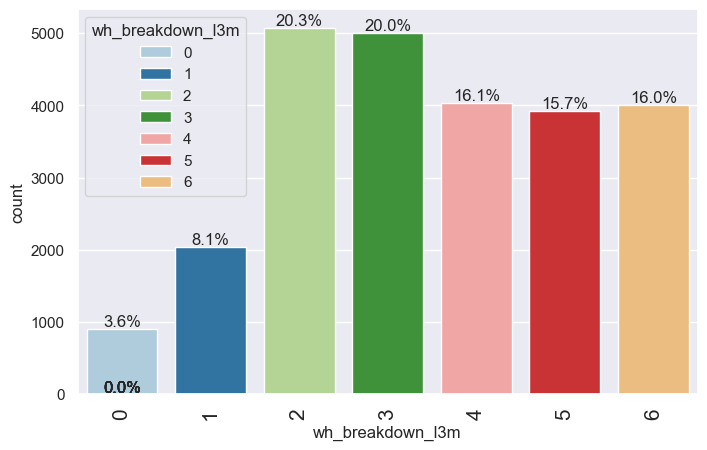

In [41]:
labeled_barplot(df, 'wh_breakdown_l3m', perc=True)

Observations:
* Warehouse breakdown frequency ranges from 0 to 6 in the last 3 months.
* Very few have reported 0 to 1 breakdowns:
    * 0 breakdown - 3.6%
    * 1 breakdown - 8.1%
* More than 15% of the warehouses have experienced 2 to 6 breakdowns.

Insights:
* A large portion of warehouses face recurring operational breakdowns.
* it may be due to worker strike, flood, electric failure which can lead to delay in deliveries, reduce in efficiency and face challenges in terms of inventory handling. These warehouses may require infrastructure maintenance, operational monitoring, etc.

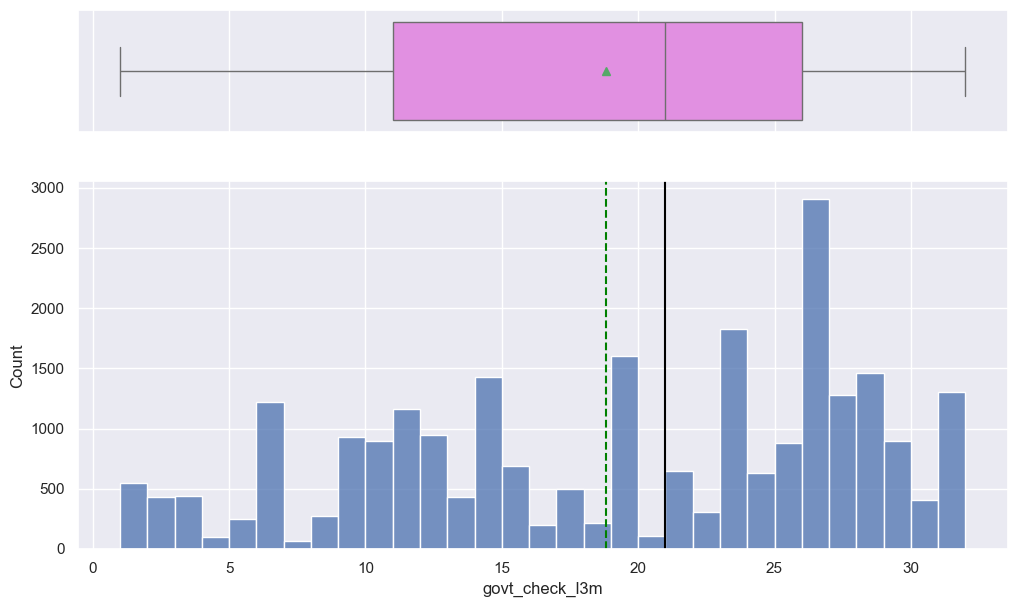

In [42]:
histogram_boxplot(df, 'govt_check_l3m')

In [43]:
df['govt_check_l3m'].describe()

count    25000.000000
mean        18.812280
std          8.632382
min          1.000000
25%         11.000000
50%         21.000000
75%         26.000000
max         32.000000
Name: govt_check_l3m, dtype: float64

Observations:
* The  distribution ranges from 1 to 32 checks in the last 3 months.
* The median is 21 and mean is 18, indicating slight left skewness.
* Most warehouses fall with 10-26 checks.
* No outliers are present.

Insights:
* The histogram shows multiple peaks, suggesting uneven inspections across warehouses.
* Variation in inspection frequency may depend on warehouse size and operational activity.

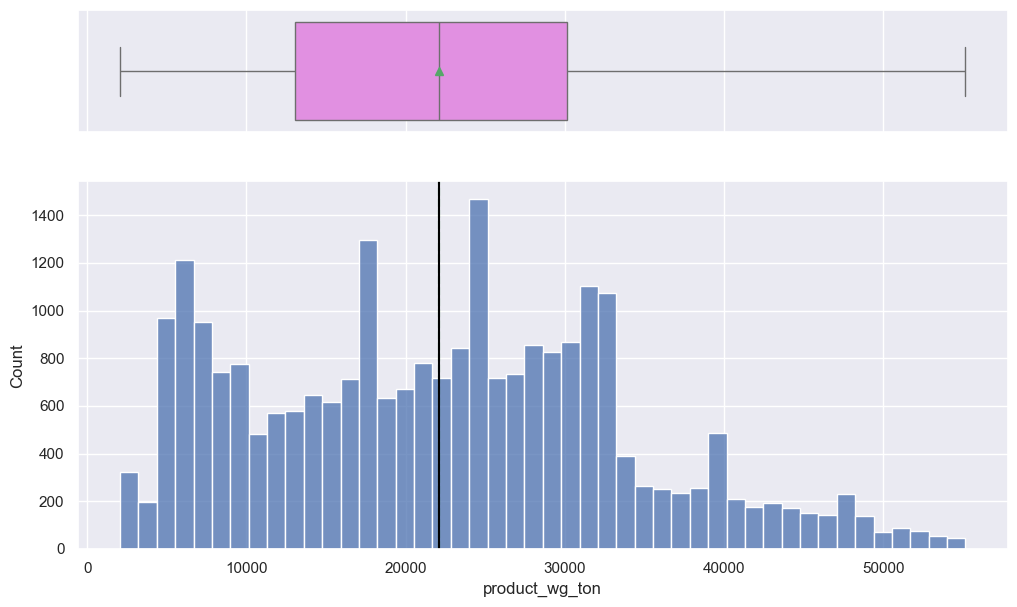

In [44]:
histogram_boxplot(df, 'product_wg_ton')

In [45]:
df['product_wg_ton'].describe()

count    25000.000000
mean     22102.632920
std      11607.755077
min       2065.000000
25%      13059.000000
50%      22101.000000
75%      30103.000000
max      55151.000000
Name: product_wg_ton, dtype: float64

Observations:
* The distribution positively skewed and ranges from 2,000 to 55,000 tons.
* The mean and median are almost similar which indicates moderate balance in the distribution.
* Most of the product weight fall between 13,000 to 30,000.
* The boxplot does not show any outliers.

Insights:
* Product movement varies significantly across warehouses, indicating diverse operational capacities ad regional demand patterns.
* Warehouse operations are not uniformly distributed across the network.

### 4. Bivariate Analysis

#### Correlation heatmap

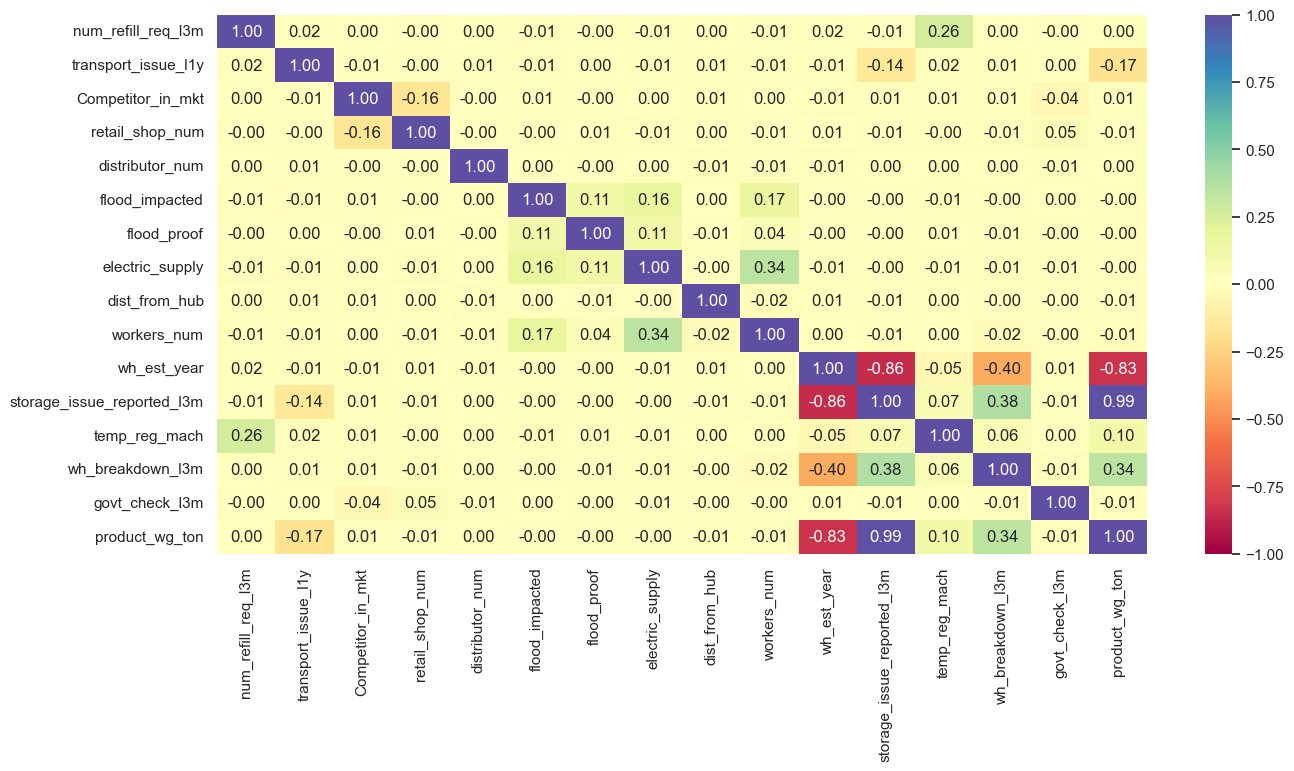

In [46]:
cols_list = df.select_dtypes(include=np.number).columns.tolist()


plt.figure(figsize=(15, 7))
sns.heatmap(
    df[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

Observations:

* product_wg_ton & storage_issue_reported_l3m (0.99) - Extremely strong positive correlation. Warehouses reporting more storage problems are associated with higher shipment quantities.
* product_wg_ton & wh_est_year (-0.83) - Strong Negative Correlation. Newer warehouses tend to ship lower quantities.
* product_wg_ton & wh_breakdown_l3m (0.34) - Moderative positive correlation. Warehouses with higher shipment quantities tend to have more operational breakdowns.
* product_wg_ton & temp_reg_mach (0.10) - Weak positive correlation. Warehouses with temperature regulation machinary may handle larger shipment quantities.
* product_wg_ton & transport_issue_l1y (-0.17) - Weak negative correlation. Transportation issues may slightly reduce shipment efficiency.
* wh_breakdown_l3m & wh_est_year (-0.40) - Moderative negative correlation. Newer warehouses have less operational breakdowns.
* wh_breakdown_l3m & storage_issue_reported_l3m (0.38) - Moderative positive correlation. Warehouses with more storage issues tend to face more operational breakdowns.
* temp_reg_mach & num_refill_req_l3m (0.26) - Warehouses with temperature regulation machinary might require more refills of products.
* storage_issue_reported_l3m & wh_est_year (-0.86) - Strong negative correlation. Older warehouses tend to report more storage related issues.
* workers_num & flood_impacted (0.17) - Weak negative correlation. Flood affected warehouses may require more workforce for maintenance and operations.
* workers_num & electric_supply (0.34) - Warehouses with electric supply tend to have more workers.
* electric_supply & flood_impacted (0.16) - Weak positive correlation. Warehouses that are impacted by flood may have backup electric systems.
* Competitor_in_mkt & retail_shop_num (-0.16) - Weak negative correlation. Regions with many competitors may have fewer retail shops selling this company's product.

#### Numerical vs Target

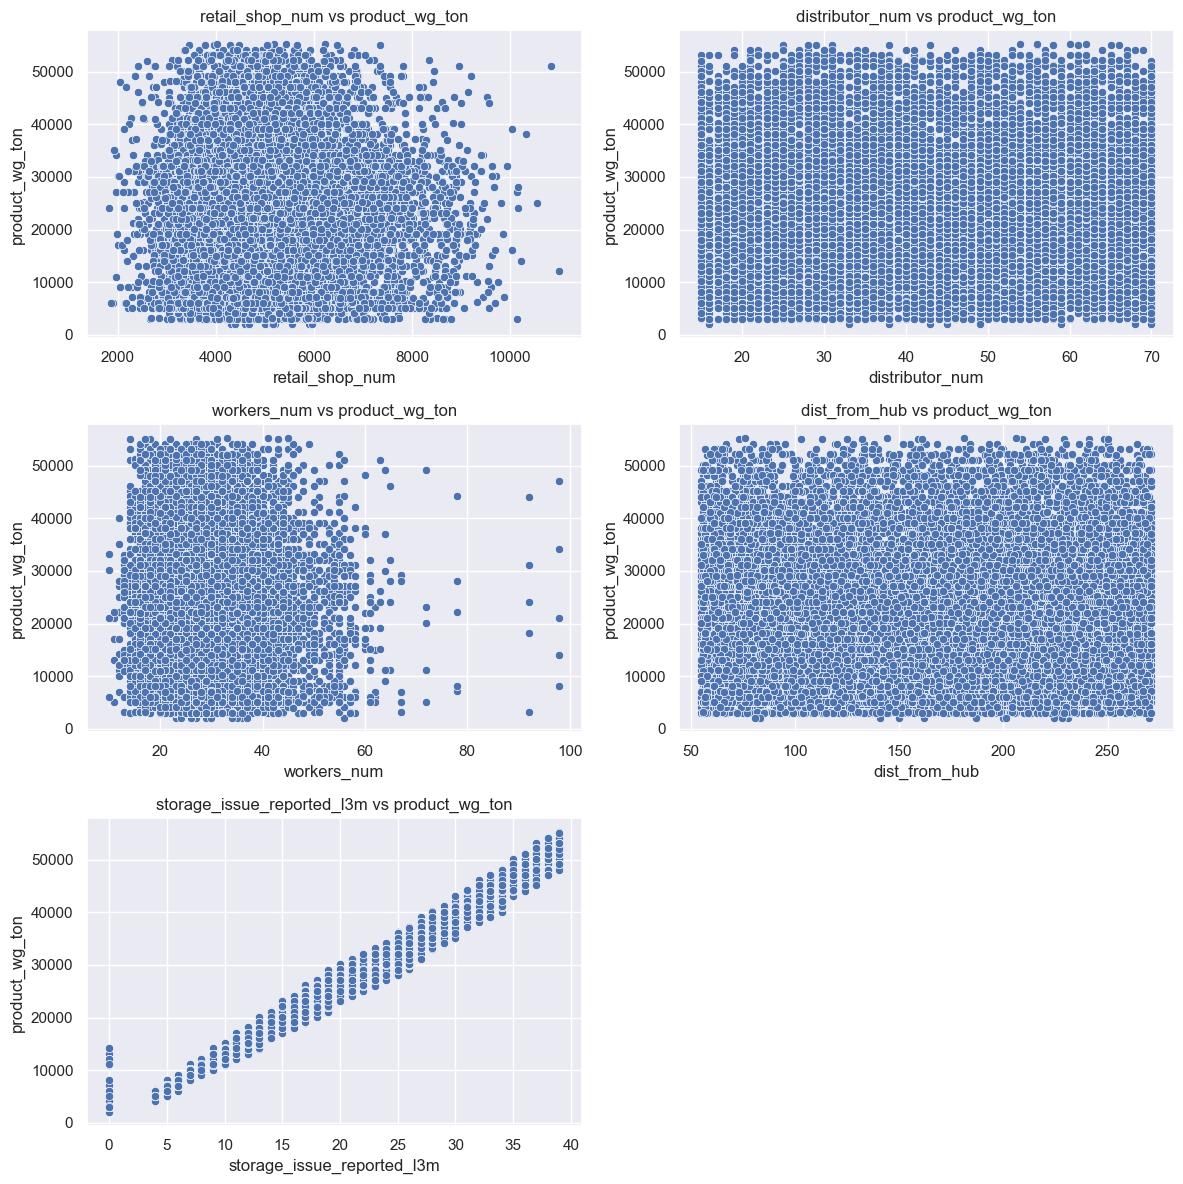

In [47]:
features = ['retail_shop_num', 'distributor_num', 'workers_num', 'dist_from_hub', 'storage_issue_reported_l3m']

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.scatterplot(
        x=df[col],
        y=df['product_wg_ton'],
        ax=axes[i]
    )
    axes[i].set_title(f'{col} vs product_wg_ton')

# turn off last empty plot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

##### retail_shop_num vs product_wg_tom
Observations:
* Most of the data points are clustered between 3000 to 8000 shops and 5000 to 50000 product weight.
* No strong trend is visible

Insights:
retail shop number alone is not a strong predictor. Some regions may generate higher throughput despite fewer shops.

##### distributor_num vs product_wg_ton
Observations:
* The data points are high dispersed.

Insights:
* Distributor count has very wear influence on throughput. 

##### workers_num vs product_wg_ton
Observations:
* Most of the warehouses work with 15-50 workers. Product weight remains highly variable across worker counts.
* Few high worker outliers exists but dont show higher throughput.

Insights:
* Workforce is alone is not correlated with shipment value, one of possible reasons could be workload imbalance. 

##### dist_from_hub vs product_wg_ton
Observations:
* Data points are evenly distributed across all hub distances.
* No trend visible.

Insights:
* Distance from the hub does not affect the product throughput.

##### storage_issue_reported_l3m vs product_wg_ton
Observations:
* Strong linear positive trend observed.
* As storage issue increases, product weight increases.

Insights:
* High volume warehouses naturally experience more storage issues. They increase operational stress.

#### Categorical vs Target

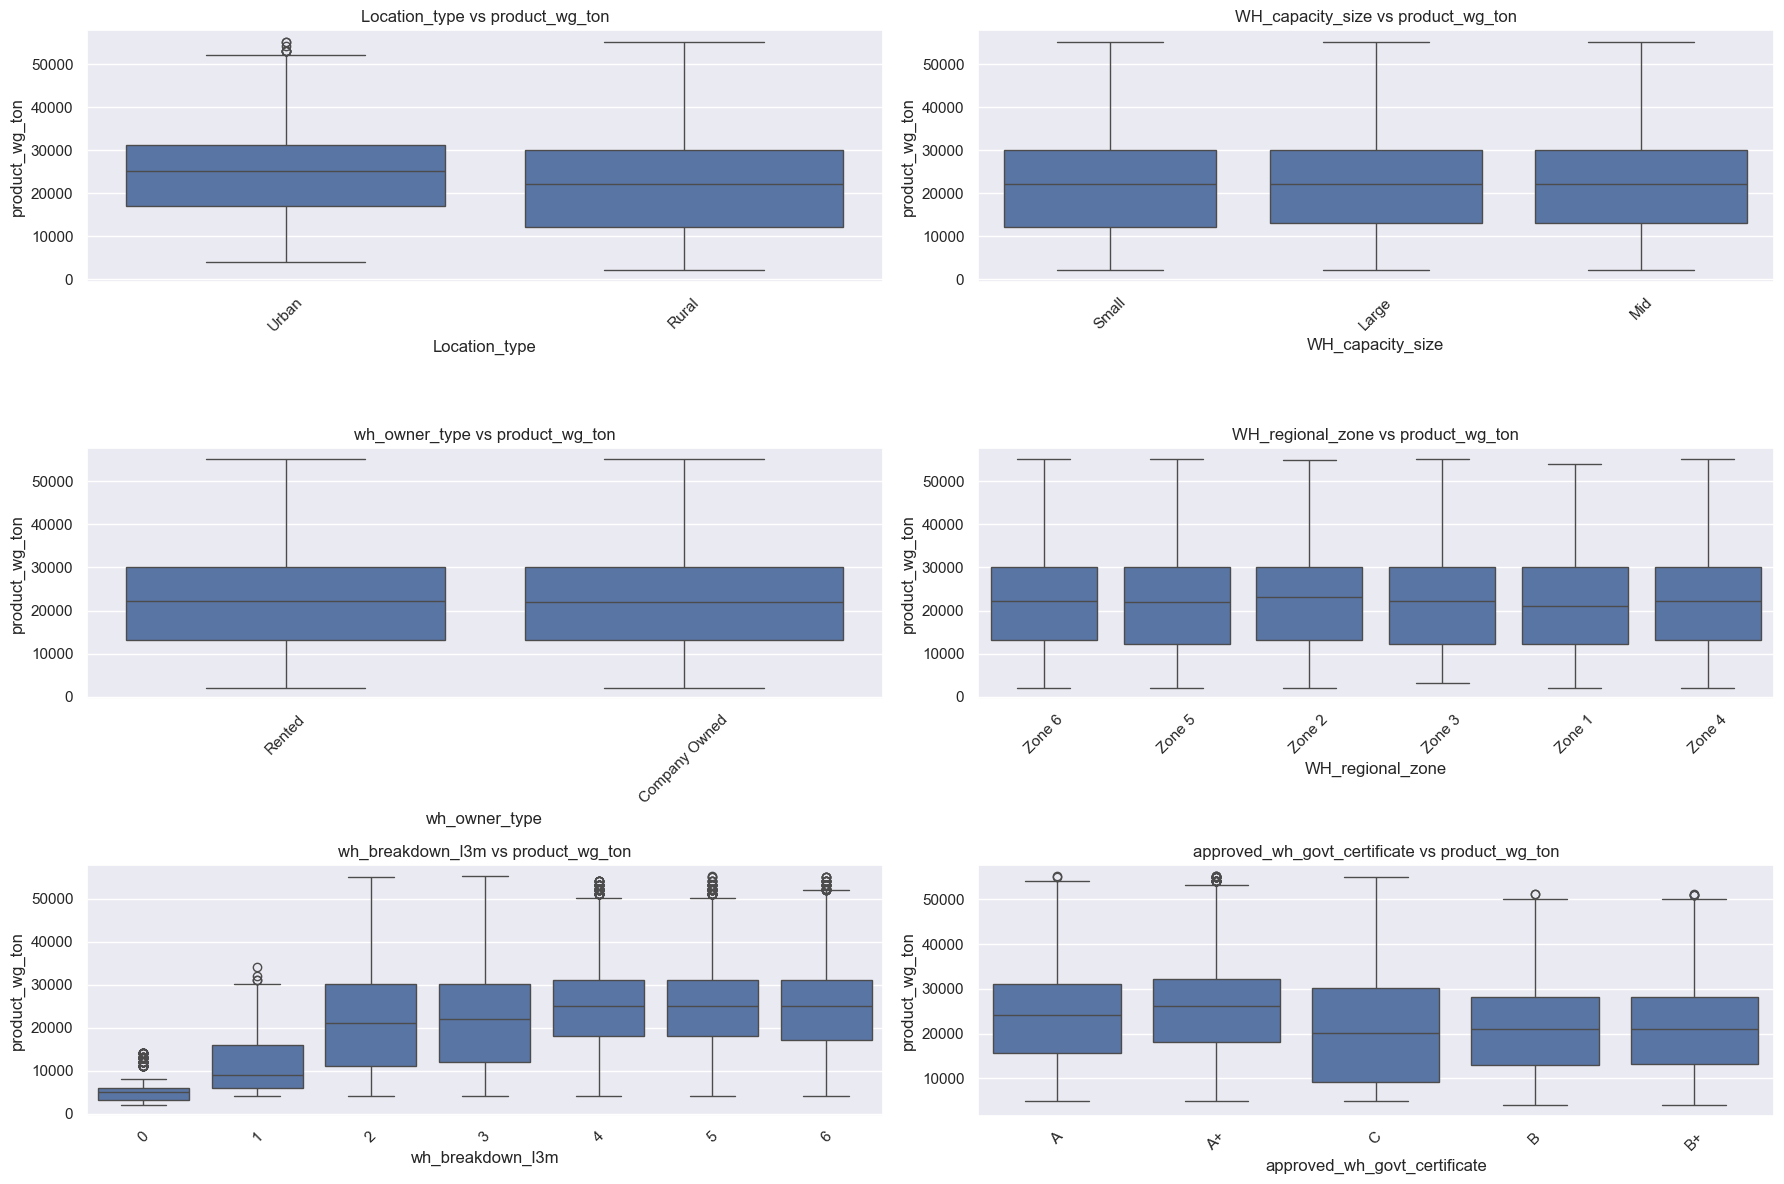

In [48]:
categorical_features = [ 'Location_type', 'WH_capacity_size', 'wh_owner_type', 'WH_regional_zone', 'wh_breakdown_l3m', 'approved_wh_govt_certificate']

fig, axes = plt.subplots(3, 2, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.boxplot(x=df[col], y=df['product_wg_ton'], ax=axes[i])
    axes[i].set_title(f'{col} vs product_wg_ton')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

##### Location_type vs product_wg_ton
Observations:
* Urban locations shows a slightly higher median than rural.
* Rural shows a wider spread.
* Urban contains a few high value outliers.

Insights:
* Urban warehouses may handle more inventory due to better infrastructure, more demand, and better logistics connectivity.
* Rural operations may face fluctuations in demand and supply. They may require more planning.

##### WH_capacity_size vs product_wg_ton
Observations:
* The medians of all 3 sizes are similar.
* Small category has a wider spread compared to Mid and Large.

Insights:
* Warehouse size alone is not a strong predictor of product ton.

##### wh_owner_type vs product_wg_ton
Observations:
* Both Rented and Company owner shows similar median and similar spread.

Insights:
* Company owned warehouses are more flexible interms of handling strategic/high volume operations.

##### WH_regional_zone vs product_wg_ton
Observations:
* All 6 regional zones show very similar distribution.
* Zone 2, 3 and 4 have a slightly higher median than the other regional zones.

Insights:
* Product movement appears geographically balanced across all 6 regional zones.
* No major imbalance exists.

##### wh_breakdown_l3m vs product_wg_ton
Observations:
* Higher breakdown frequency corresponds to higher product weight.
* Warehouses with 4-6 breakdowns show significantly higher median product weight.

Insights:
* High volume warehouses experience more operational stress.
* Large throughput increases equipment which increases breakdown probability.

##### approved_wh_govt_certificate vs product_wg_ton
Observations:
* All 5 categories show moderate difference.
* Category C appears to have lower throughput and larger variability.

Insights:
* Government certified warehouses may handle large scale operations and follow stricter protocols.
* Certifications may positively influence product throughput.

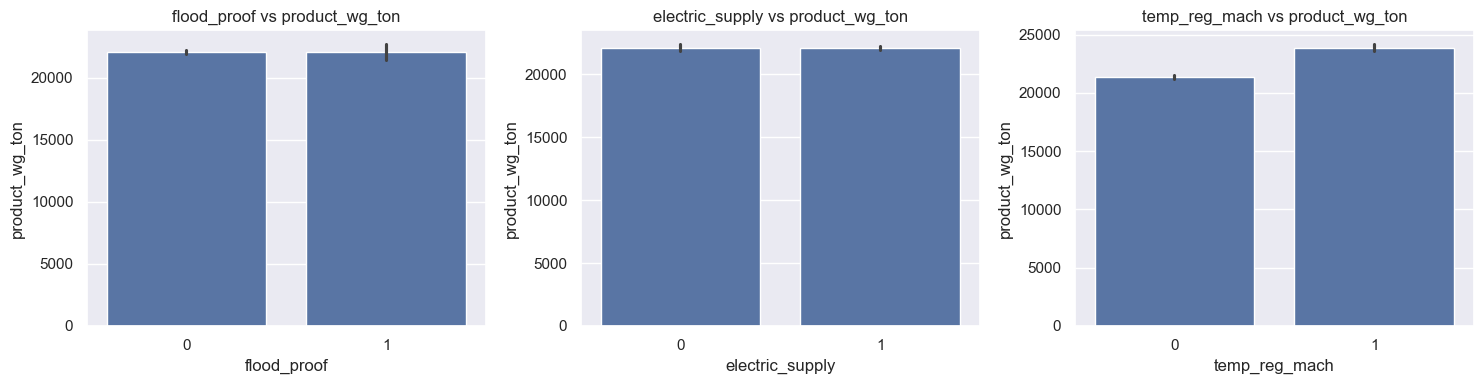

In [49]:
#Binary columns
binary_features = ['flood_proof', 'electric_supply', 'temp_reg_mach']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(binary_features):
    sns.barplot(x=col, y='product_wg_ton', data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs product_wg_ton')

plt.tight_layout()
plt.show()

flood_proof vs product_wg_ton
* Both categories 1 and 0 show almost identical average product weight.

electric_supply vs product_wg_ton
* Both categories 1 and 0 show almost identical average product weight.

temp_reg_mach vs product_wg_ton
* Warehouses with temperature regulating machines show higher average product weight than those without.

Insights:
* Flood proof capability and electric infrastructure does not significantly increase product movement.
* Temperature regulated facilities are associated with high product movement. It may indicate higher capacity warehouses, better infrastructure, good product handling, efficient inventory management.

### 5. Multivariate Analysis

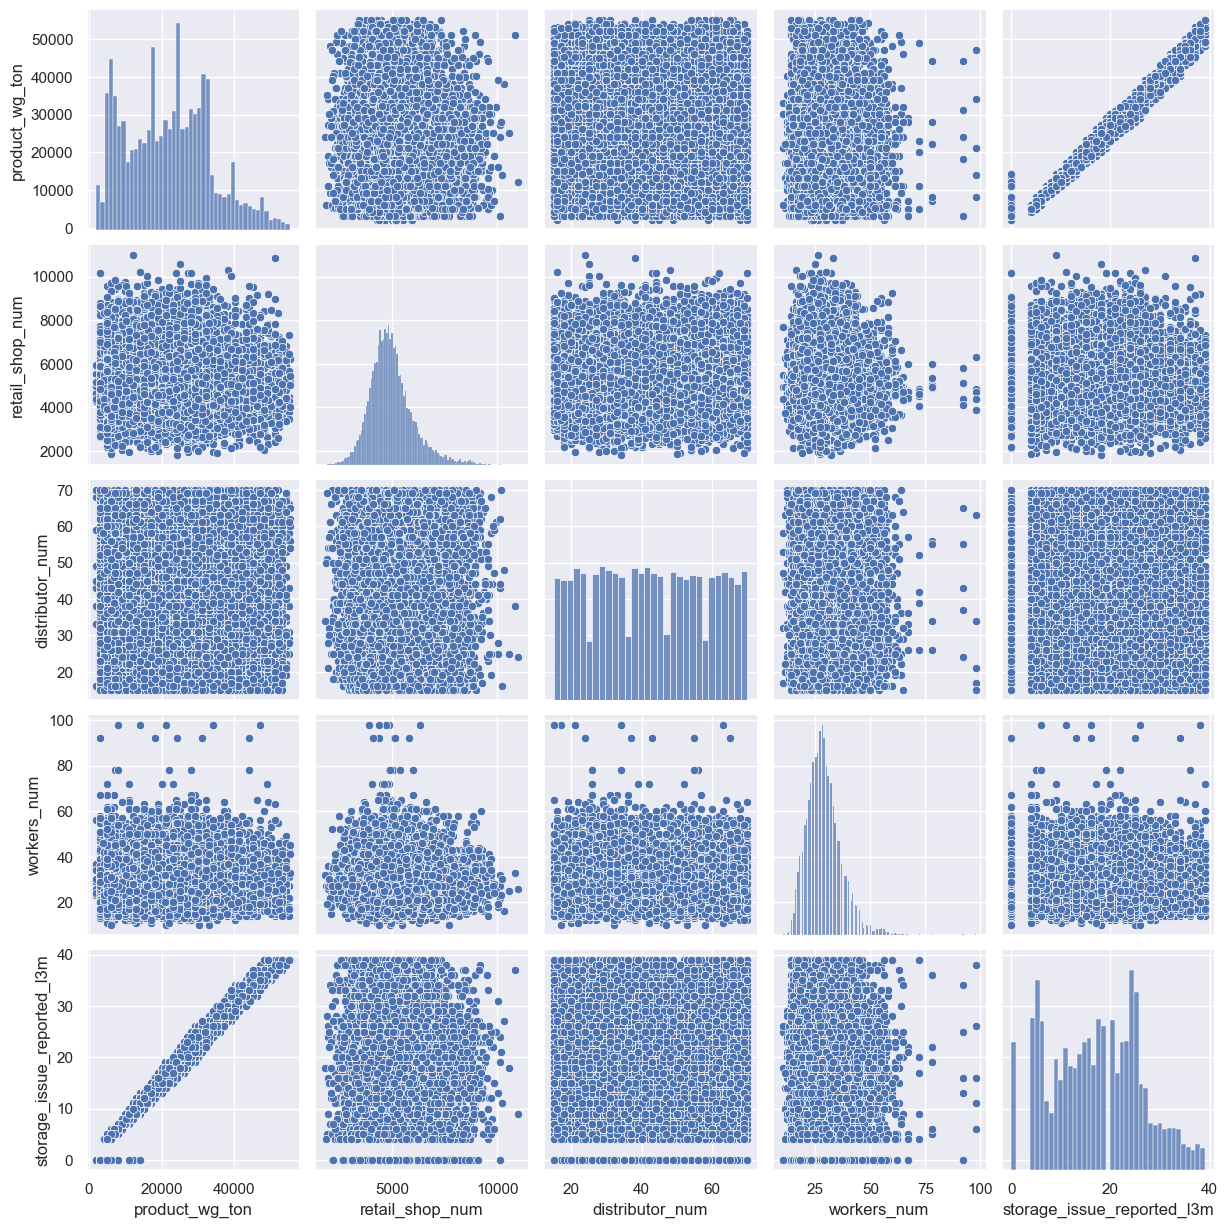

In [50]:
selected_cols = [
    'product_wg_ton',
    'retail_shop_num',
    'distributor_num',
    'workers_num',
    'storage_issue_reported_l3m',
]

sns.pairplot(df[selected_cols])

plt.show()

Observations:
* The pairplot indicates that several variables exhibit non-linear or weak relationships with the target variable, which may limit the performance of simple linear models.
* product_wg_ton shows a very strong positive relationship with storage_issue_reported_l3m.
* Warehouses with larger product quantity tend to have more storage issues.
* retail_shop_num does not show any linear relationship but moderate clustering patterns are visible.
* distributor_num is evenly distributed and does not exhibit strong direct correlation with product movement.
* workers_num appears moderately concentrated within a limited range, suggesting workforce allocation is relatively standardized across warehouses.

### DATA PREPROCESSING

### 1. Duplicate value check

In [51]:
df.duplicated().sum()

0

### 2. Data cleaning

In [52]:
#Drop Ware_house_ID & WH_Manager_ID column from the dataset
df.drop('Ware_house_ID', axis=1, inplace=True)
df.drop('WH_Manager_ID', axis=1, inplace=True)

'Ware_house_ID' and 'WH_Manager_ID' are removed as they do not contribute any meaningful information.

### 3. Anomalous value check

In [53]:
#Check for negative values
(df.select_dtypes(include=np.number)<0).sum()

num_refill_req_l3m            0
transport_issue_l1y           0
Competitor_in_mkt             0
retail_shop_num               0
distributor_num               0
flood_impacted                0
flood_proof                   0
electric_supply               0
dist_from_hub                 0
workers_num                   0
wh_est_year                   0
storage_issue_reported_l3m    0
temp_reg_mach                 0
wh_breakdown_l3m              0
govt_check_l3m                0
product_wg_ton                0
dtype: int64

* There are no negative values in the dataset.

In [54]:
#Check binary columns
binary_cols = [
    'flood_impacted',
    'flood_proof',
    'electric_supply',
    'temp_reg_mach'
]

for col in binary_cols:
    print(col, df[col].unique())

flood_impacted [0 1]
flood_proof [1 0]
electric_supply [1 0]
temp_reg_mach [0 1]


* Anomalous value check was performed on numerical and categorical datatype. There are no negative values found and binary variables are also consistent.

### 4. Missing value check

In [55]:
df.isnull().sum()

Location_type                       0
WH_capacity_size                    0
zone                                0
WH_regional_zone                    0
num_refill_req_l3m                  0
transport_issue_l1y                 0
Competitor_in_mkt                   0
retail_shop_num                     0
wh_owner_type                       0
distributor_num                     0
flood_impacted                      0
flood_proof                         0
electric_supply                     0
dist_from_hub                       0
workers_num                       990
wh_est_year                     11881
storage_issue_reported_l3m          0
temp_reg_mach                       0
approved_wh_govt_certificate      908
wh_breakdown_l3m                    0
govt_check_l3m                      0
product_wg_ton                      0
dtype: int64

* 3 variables have missing values:
  * workers_num - 990
  * wh_est_year - 11881
  * approved_wh_govt_certificate - 908

In [56]:
# 'workers_num' - apply median
df['workers_num'] = pd.to_numeric(df['workers_num'])
df['workers_num'] = df['workers_num'].fillna(df['workers_num'].median())

In [57]:
# 'approved_wh_govt_certificate' - apply mode
df['approved_wh_govt_certificate'] = df['approved_wh_govt_certificate'].fillna(df['approved_wh_govt_certificate'].mode()[0])

In [58]:
# 'approved_wh_govt_certificate' 
missing_percent = (df['wh_est_year'].isna().sum() / len(df)) * 100
print(missing_percent)

47.524


* Since 47.52% are missing values, we must handle it properly. We will perform feature engineering for this variable.

In [59]:
df.isnull().sum()

Location_type                       0
WH_capacity_size                    0
zone                                0
WH_regional_zone                    0
num_refill_req_l3m                  0
transport_issue_l1y                 0
Competitor_in_mkt                   0
retail_shop_num                     0
wh_owner_type                       0
distributor_num                     0
flood_impacted                      0
flood_proof                         0
electric_supply                     0
dist_from_hub                       0
workers_num                         0
wh_est_year                     11881
storage_issue_reported_l3m          0
temp_reg_mach                       0
approved_wh_govt_certificate        0
wh_breakdown_l3m                    0
govt_check_l3m                      0
product_wg_ton                      0
dtype: int64

Observations:
* workers_num - is a numerical feature, missing values were imputed using median.
* approved_wh_govt_certificate - is a categorical feature, missing values were imputed using mode.
* wh_est_year - has large number of missing value. we will perform feature engineering on it.

### 5. Feature Engineering

#### Warehouse Age (wh_age)

In [60]:
#convert into numeric
df['wh_est_year'] = pd.to_numeric(df['wh_est_year'])

#Warehouse age
df['wh_age'] = 2026 - df['wh_est_year']

#Missing indicator
df['wh_age_missing'] = df['wh_age'].isna().astype(int)

#impute missing values using median
df['wh_age'] = df['wh_age'].fillna(df['wh_age'].median())

In [61]:
df.isnull().sum()

Location_type                       0
WH_capacity_size                    0
zone                                0
WH_regional_zone                    0
num_refill_req_l3m                  0
transport_issue_l1y                 0
Competitor_in_mkt                   0
retail_shop_num                     0
wh_owner_type                       0
distributor_num                     0
flood_impacted                      0
flood_proof                         0
electric_supply                     0
dist_from_hub                       0
workers_num                         0
wh_est_year                     11881
storage_issue_reported_l3m          0
temp_reg_mach                       0
approved_wh_govt_certificate        0
wh_breakdown_l3m                    0
govt_check_l3m                      0
product_wg_ton                      0
wh_age                              0
wh_age_missing                      0
dtype: int64

In [62]:
#drop 'wh_est_year' as 'wh_age' contains useful information
df.drop('wh_est_year', axis=1, inplace=True)

#### Infrastructure score (infra_score)

In [63]:
df['infra_score'] = ( df['electric_supply'] + df['flood_proof'] + df['temp_reg_mach'])

In [64]:
df['infra_score']

0        2
1        1
2        0
3        1
4        1
        ..
24995    2
24996    1
24997    1
24998    1
24999    2
Name: infra_score, Length: 25000, dtype: int64

In [65]:
df.drop(['electric_supply', 'flood_proof', 'temp_reg_mach'], axis=1, inplace=True)

### 6. Outlier check

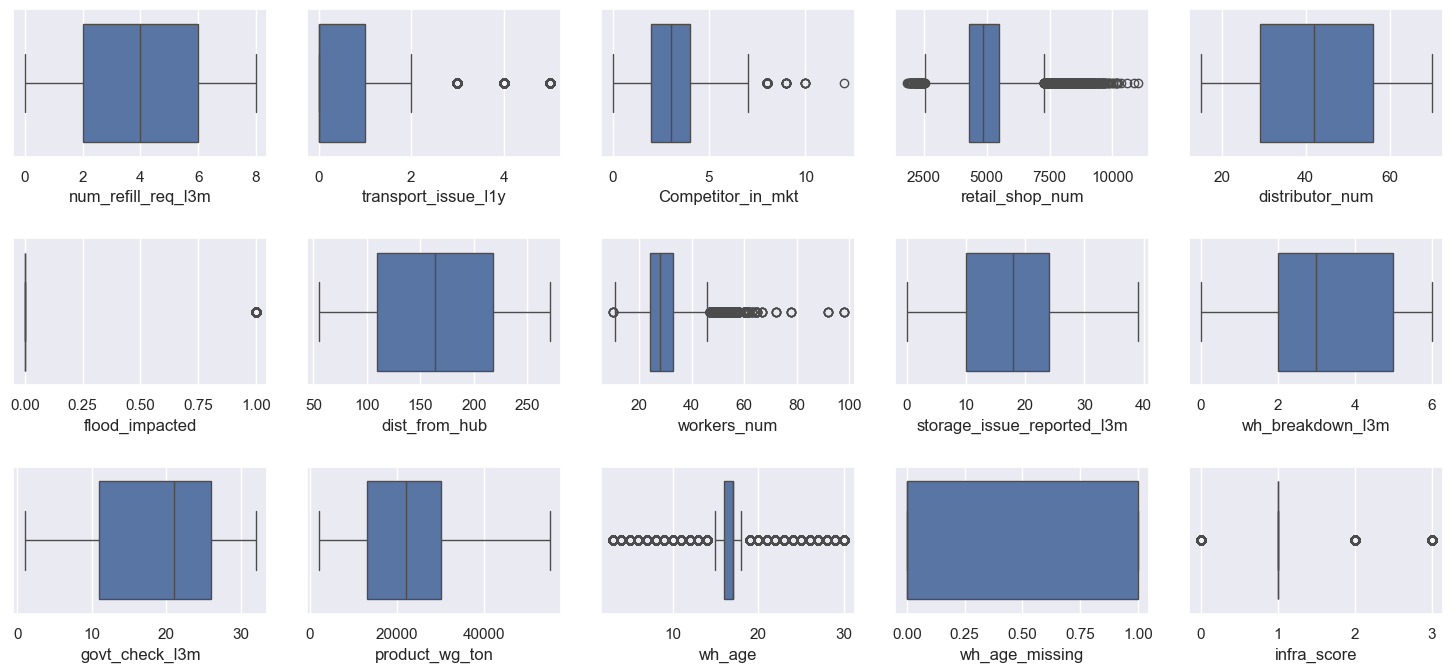

In [66]:
# outlier detection using boxplot
num_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 9))

for i, variable in enumerate(num_cols):
    plt.subplot(4,5, i + 1)
    sns.boxplot(data=df, x=variable)
    plt.tight_layout(pad=2)

plt.show()

In [67]:
#Outler treatment - Capping
outlier_cols = ['retail_shop_num', 'workers_num', 'Competitor_in_mkt', 'product_wg_ton']

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    
    lower = Q1-1.5*IQR
    upper = Q3+1.5*IQR

    df[col] = df[col].clip(lower,upper)

### 7. Class imbalance handling

* Since this is a regression based problem, class imbalance handling techniques were not applicable.

### 8. Feature scaling

* We will use StandardScaler in the upcoming section.

### DATA PREPARATION FOR MODELLING

In [68]:
# defining X and y variables
X = df.drop(["product_wg_ton"], axis=1)
y = df["product_wg_ton"]

In [69]:
# let's add the intercept to data
X = sm.add_constant(X)

In [70]:
# creating dummy variables
X = pd.get_dummies(
    X,
    columns=X.select_dtypes(include=["object", "category"]).columns.tolist(),
    drop_first=True
)

X.head()

,const,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,distributor_num,flood_impacted,dist_from_hub,workers_num,storage_issue_reported_l3m,wh_breakdown_l3m,govt_check_l3m,wh_age,wh_age_missing,infra_score,Location_type_Urban,WH_capacity_size_Mid,WH_capacity_size_Small,zone_North,zone_South,zone_West,WH_regional_zone_Zone 2,WH_regional_zone_Zone 3,WH_regional_zone_Zone 4,WH_regional_zone_Zone 5,WH_regional_zone_Zone 6,wh_owner_type_Rented,approved_wh_govt_certificate_A+,approved_wh_govt_certificate_B,approved_wh_govt_certificate_B+,approved_wh_govt_certificate_C
0,1.0,3,1,2,4651.0,24,0,91,29.0,13,5,15,17.0,1,2,True,False,True,False,False,True,False,False,False,False,True,True,False,False,False,False
1,1.0,0,0,4,6217.0,47,0,210,31.0,4,3,17,17.0,1,1,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False
2,1.0,1,0,4,4306.0,64,0,161,37.0,17,6,22,17.0,1,0,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,False
3,1.0,7,4,2,6000.0,50,0,103,21.0,17,3,27,17.0,1,1,False,True,False,True,False,False,False,True,False,False,False,True,True,False,False,False
4,1.0,3,1,2,4740.0,42,1,112,25.0,18,6,24,17.0,0,1,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True


In [71]:
# converting the input attributes into float type for modeling
X = X.astype(float)
X.head()

,const,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,distributor_num,flood_impacted,dist_from_hub,workers_num,storage_issue_reported_l3m,wh_breakdown_l3m,govt_check_l3m,wh_age,wh_age_missing,infra_score,Location_type_Urban,WH_capacity_size_Mid,WH_capacity_size_Small,zone_North,zone_South,zone_West,WH_regional_zone_Zone 2,WH_regional_zone_Zone 3,WH_regional_zone_Zone 4,WH_regional_zone_Zone 5,WH_regional_zone_Zone 6,wh_owner_type_Rented,approved_wh_govt_certificate_A+,approved_wh_govt_certificate_B,approved_wh_govt_certificate_B+,approved_wh_govt_certificate_C
0,1.0,3.0,1.0,2.0,4651.0,24.0,0.0,91.0,29.0,13.0,5.0,15.0,17.0,1.0,2.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,4.0,6217.0,47.0,0.0,210.0,31.0,4.0,3.0,17.0,17.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,1.0,0.0,4.0,4306.0,64.0,0.0,161.0,37.0,17.0,6.0,22.0,17.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,7.0,4.0,2.0,6000.0,50.0,0.0,103.0,21.0,17.0,3.0,27.0,17.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4,1.0,3.0,1.0,2.0,4740.0,42.0,1.0,112.0,25.0,18.0,6.0,24.0,17.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [72]:
# splitting the data in 80:20 ratio for train to test data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [73]:
print("Number of rows in train data =", X_train.shape[0])
print("Number of rows in test data =", X_test.shape[0])

Number of rows in train data = 20000
Number of rows in test data = 5000


### Feature Scaling

In [74]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### MODEL BUILDING - BASELINE MODEL

In [75]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [76]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute MAPE
def mape_score(targets, predictions):
    return np.mean(np.abs(targets - predictions) / targets) * 100


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mape_score(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

In [77]:
# checking model performance on train set
print("Training Performance\n")
lr_train_perf = model_performance_regression(lr_model, X_train_scaled, y_train)
lr_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,1384.531489,1008.753454,0.985803,0.98578,7.607982


* Low RMSE(1384.53) and MAE(1008.75) indicates low prediction error and that predictions are close to the actual values.
* Model explains 98.5% variance in training data.
* Average prediction error is approximately 7.6%.

In [78]:
# checking model performance on test set
print("Testing Performance\n")
lr_test_perf = model_performance_regression(lr_model, X_test_scaled, y_test)
lr_test_perf

Testing Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,1336.957362,993.37605,0.986619,0.986535,7.403258


* Low RMSE(1336.95) and MAE(993.37) indicates low prediction error and that predictions are close to the actual values.
* Model explains 98.6% variance in training data.
* Average prediction error is approximately 7.4%.

Overall:
* LR model demonstrates very strong predictive performance on both training and testing sets.
* The values of train and test metrics are very close, indicating good generalisation and maybe overfitting.
* The high performance may be influenced by 'storage_issue_reported_l3m' as it was highly correlated.
#### Since correlation between product_wg_ton and storage_issue_reported_l3m is 0.99, we'll try another model without storage_issue_reported_l3m feature.

In [79]:
# Creating a new dataframe without the suspicious feature

df1 = df.drop('storage_issue_reported_l3m', axis=1)

In [80]:
X = df1.drop('product_wg_ton', axis=1)
y = df1['product_wg_ton']

In [81]:
X = pd.get_dummies(X,drop_first=True)
X

,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,distributor_num,flood_impacted,dist_from_hub,workers_num,wh_breakdown_l3m,govt_check_l3m,wh_age,wh_age_missing,infra_score,Location_type_Urban,WH_capacity_size_Mid,WH_capacity_size_Small,zone_North,zone_South,zone_West,WH_regional_zone_Zone 2,WH_regional_zone_Zone 3,WH_regional_zone_Zone 4,WH_regional_zone_Zone 5,WH_regional_zone_Zone 6,wh_owner_type_Rented,approved_wh_govt_certificate_A+,approved_wh_govt_certificate_B,approved_wh_govt_certificate_B+,approved_wh_govt_certificate_C
0,3,1,2,4651.0,24,0,91,29.0,5,15,17.0,1,2,True,False,True,False,False,True,False,False,False,False,True,True,False,False,False,False
1,0,0,4,6217.0,47,0,210,31.0,3,17,17.0,1,1,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False
2,1,0,4,4306.0,64,0,161,37.0,6,22,17.0,1,0,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,False
3,7,4,2,6000.0,50,0,103,21.0,3,27,17.0,1,1,False,True,False,True,False,False,False,True,False,False,False,True,True,False,False,False
4,3,1,2,4740.0,42,1,112,25.0,6,24,17.0,0,1,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,3,0,4,5390.0,19,0,142,34.0,2,30,21.0,0,2,False,False,True,True,False,False,False,False,False,False,False,True,False,False,False,False
24996,6,0,4,4490.0,57,0,130,28.0,4,18,14.0,0,1,False,True,False,False,False,True,True,False,False,False,False,False,False,True,False,False
24997,7,0,2,5403.0,31,1,147,28.0,5,25,17.0,1,1,True,False,False,False,True,False,False,False,False,True,False,True,False,False,True,False
24998,1,0,2,7280.5,25,0,60,25.0,6,30,17.0,1,1,False,False,True,True,False,False,False,False,False,False,False,True,False,False,False,False


In [82]:
# convert all columns to numeric
X = X.astype(float)

In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [84]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [85]:
X_train_scaled

array([[-1.18883785,  0.18859185,  0.81537392, ..., -0.48966507,
         2.01767042, -0.58597251],
       [ 1.49684761, -0.64662448, -0.08355549, ..., -0.48966507,
        -0.49562108, -0.58597251],
       [ 1.49684761, -0.64662448,  0.81537392, ..., -0.48966507,
        -0.49562108, -0.58597251],
       ...,
       [ 1.11317826,  0.18859185, -0.08355549, ..., -0.48966507,
        -0.49562108,  1.7065647 ],
       [-1.18883785, -0.64662448, -0.9824849 , ...,  2.04221224,
        -0.49562108, -0.58597251],
       [-0.8051685 , -0.64662448, -0.08355549, ..., -0.48966507,
         2.01767042, -0.58597251]])

In [86]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [87]:
# checking model performance on train set (seen 70% data)
print("Training Performance\n")
lr_train_perf = model_performance_regression(lr_model, X_train_scaled, y_train)
lr_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,8409.48471,6621.440294,0.476028,0.475267,48.146689


* RMSE(8409.48) and MAE(6621.44) increased significantly.
* Now models explains only 47.6% variance in training data.
* Average prediction error is approximately 48%.

In [88]:
# checking model performance on test set (seen 30% data)
print("Testing Performance\n")
lr_test_perf = model_performance_regression(lr_model, X_test_scaled, y_test)
lr_test_perf

Testing Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,8351.162596,6615.681498,0.478759,0.475718,48.384469


* RMSE(8351.16) and MAE(6615.68) increased significantly.
* Now models explains only 47.8% variance in training data.
* Average prediction error is approximately 48%.

##### Conclusion:
After removing 'storage_issue_reported_l3m' feature, model performance dropped significantly. This indicates that the feature had very strong relationship with the target variable. 
Although 47.9% is moderate, the model is considered more realistic and reliable for practical business applications. 
Model 2 can serve as a baseline model for future improvements using advanced machine learning algorithms.


In [89]:
X_train.describe()

,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,distributor_num,flood_impacted,dist_from_hub,workers_num,wh_breakdown_l3m,govt_check_l3m,wh_age,wh_age_missing,infra_score,Location_type_Urban,WH_capacity_size_Mid,WH_capacity_size_Small,zone_North,zone_South,zone_West,WH_regional_zone_Zone 2,WH_regional_zone_Zone 3,WH_regional_zone_Zone 4,WH_regional_zone_Zone 5,WH_regional_zone_Zone 6,wh_owner_type_Rented,approved_wh_govt_certificate_A+,approved_wh_govt_certificate_B,approved_wh_govt_certificate_B+,approved_wh_govt_certificate_C
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,4.098600,0.774200,3.092950,4960.461150,42.432750,0.100650,163.141500,28.773300,3.483250,18.844800,16.800800,0.473900,1.015200,0.082050,0.401500,0.190800,0.409150,0.255350,0.318600,0.119950,0.115250,0.166300,0.183150,0.333150,0.458600,0.165850,0.193400,0.197200,0.255600
std,2.606476,1.197325,1.112462,967.640396,16.026192,0.300872,62.700012,7.137383,1.687176,8.619868,5.464212,0.499331,0.714909,0.274448,0.490214,0.392942,0.491689,0.436069,0.465945,0.324911,0.319331,0.372359,0.386799,0.471351,0.498296,0.371955,0.394974,0.397895,0.436209
min,0.000000,0.000000,0.000000,2532.500000,15.000000,0.000000,55.000000,10.500000,0.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,2.000000,4316.000000,29.000000,0.000000,109.000000,24.000000,2.000000,11.000000,16.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,0.000000,3.000000,4860.000000,42.000000,0.000000,163.000000,28.000000,3.000000,21.000000,17.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6.000000,1.000000,4.000000,5498.000000,56.000000,0.000000,217.000000,33.000000,5.000000,26.000000,17.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,8.000000,5.000000,7.000000,7280.500000,70.000000,1.000000,271.000000,46.500000,6.000000,32.000000,30.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### MODEL BUILDING - ADVANCED MODELS

We'll use df1 (without 'storage_issue_reported_l3m') for all models. Orelse it will give unrealistically high scores.

In [90]:
#importing models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from sklearn import metrics
from sklearn.model_selection import GridSearchCV

In [91]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute MAPE
def mape_score(targets, predictions):
    return np.mean(np.abs(targets - predictions) / targets) * 100


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mape_score(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

In [92]:
##  Function to calculate r2_score and RMSE on train and test data
def get_model_score(model, flag=True):
    '''
    model : classifier to predict values of X

    '''
    # defining an empty list to store train and test results
    score_list=[]

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    train_r2=metrics.r2_score(y_train,pred_train)
    test_r2=metrics.r2_score(y_test,pred_test)
    train_rmse=np.sqrt(metrics.mean_squared_error(y_train,pred_train))
    test_rmse=np.sqrt(metrics.mean_squared_error(y_test,pred_test))

    #Adding all scores in the list
    score_list.extend((train_r2,test_r2,train_rmse,test_rmse))

    # If the flag is set to True then only the following print statements will be dispayed, the default value is True
    if flag==True:
        print("R-sqaure on training set : ",metrics.r2_score(y_train,pred_train))
        print("R-square on test set : ",metrics.r2_score(y_test,pred_test))
        print("RMSE on training set : ",np.sqrt(metrics.mean_squared_error(y_train,pred_train)))
        print("RMSE on test set : ",np.sqrt(metrics.mean_squared_error(y_test,pred_test)))

    # returning the list with train and test scores
    return score_list

#### 1. Decision Tree

In [93]:
dtree=DecisionTreeRegressor(random_state=1)
dtree.fit(X_train,y_train)

DecisionTreeRegressor(random_state=1)

In [94]:
dtree_model_train_perf=model_performance_regression(dtree, X_train,y_train)
print("Training performance \n",dtree_model_train_perf)

Training performance 
    RMSE  MAE  R-squared  Adj. R-squared  MAPE
0   0.0  0.0        1.0             1.0   0.0


In [95]:
dtree_model_test_perf=model_performance_regression(dtree, X_test,y_test)
print("Testing performance \n",dtree_model_test_perf)

Testing performance 
           RMSE        MAE  R-squared  Adj. R-squared       MAPE
0  11008.27926  8217.1224   0.094302        0.089018  50.078199


Observations:
* The training model shows severe overfitting. The tree has memorised the training data perfectly.
* Training model has a perfect score with RMSE = 0 and R²=1
* The model performs very poorly on the unseen data with RMSE = 11008.27 and R²=0.09
* MAPE of 50.08% indicates large prediction error on the testing data.
* Decision Tree model fails to generalise.

#### 2. Bagging Regressor

In [96]:
bagging_regressor = BaggingRegressor(random_state=1)
bagging_regressor.fit(X_train, y_train)

BaggingRegressor(random_state=1)

In [97]:
bagging_regressor_model_train_perf = model_performance_regression(bagging_regressor, X_train, y_train)
print("Training performance \n", bagging_regressor_model_train_perf)

Training performance 
           RMSE         MAE  R-squared  Adj. R-squared       MAPE
0  3484.673452  2466.50077   0.910031          0.9099  15.819252


In [98]:
bagging_regressor_model_test_perf = model_performance_regression(bagging_regressor, X_test, y_test)
print("Testing performance \n", bagging_regressor_model_test_perf)

Testing performance 
           RMSE        MAE  R-squared  Adj. R-squared       MAPE
0  8270.284123  6277.4926   0.488807        0.485824  40.945374


Observations:
* Training model shows strong performance with RMSE = 3484.67 and R²=0.9.
* Testing model shows moderate performance with RMSE = 8270.28 and R²=0.48.
* MAPE of 40.95% indicates moderate prediction accuracy.
* Bagging Regressor model reduced overfitting compared to Decision Tree.

#### 3. Random Forest

In [99]:
rf = RandomForestRegressor(random_state=1)
rf.fit(X_train,y_train)

RandomForestRegressor(random_state=1)

In [100]:
rf_model_train_perf = model_performance_regression(rf, X_train,y_train)
print("Training performance \n",rf_model_train_perf)

Training performance 
           RMSE         MAE  R-squared  Adj. R-squared       MAPE
0  2966.519524  2248.54277   0.934798        0.934703  14.696167


In [101]:
rf_model_test_perf = model_performance_regression(rf, X_test,y_test)
print("Testing performance \n",rf_model_test_perf)

Testing performance 
           RMSE          MAE  R-squared  Adj. R-squared       MAPE
0  7813.644927  5972.880692   0.543699        0.541036  39.348977


Observations:
* Training model shows much better performance than Bagging with RMSE = 2966.51 and R²=0.93.
* The training performance shows the lowest error so far.
* Testing model still shows moderate performance with RMSE = 7813.66 and R²=0.54 but better than Bagging Regressor.
* MAPE of testing shows 39.34% indicating low prediction error.
* Random Forest shows strong predictive capability and better generalisation.

#### 4. AdaBoost Regressor

In [102]:
ab_regressor = AdaBoostRegressor(random_state=1)
ab_regressor.fit(X_train, y_train)

AdaBoostRegressor(random_state=1)

In [103]:
ab_regressor_model_train_perf = model_performance_regression(ab_regressor, X_train, y_train)
print("Training performance \n", ab_regressor_model_train_perf)

Training performance 
           RMSE          MAE  R-squared  Adj. R-squared       MAPE
0  8235.857934  6575.149384   0.497441        0.496712  48.639448


In [104]:
ab_regressor_model_test_perf = model_performance_regression(ab_regressor, X_test, y_test)
print("Testing performance \n", ab_regressor_model_test_perf)

Testing performance 
           RMSE          MAE  R-squared  Adj. R-squared       MAPE
0  8162.607733  6526.453634   0.502031        0.499125  48.432275


Observations:
* Moderate training performance with RMSE = 8235.85 and R²=0.49
* The training models shows high training errors.
* The testing performance shows similar values to training with RMSE = 8162.60 and R²=0.50.
* MAPE of testing is similar to training with 48.43%.
* AdaBoost Regressor shows stable performance but weaker compared to other models.

#### 5. Gradient Boosting Regressor

In [105]:
gb = GradientBoostingRegressor(random_state=1)
gb.fit(X_train, y_train)

GradientBoostingRegressor(random_state=1)

In [106]:
gb_model_train_perf = model_performance_regression(gb, X_train, y_train)
print("Training performance:\n", gb_model_train_perf)

Training performance:
           RMSE          MAE  R-squared  Adj. R-squared       MAPE
0  7700.227383  5906.217346   0.560685        0.560047  38.894246


In [107]:
gb_model_test_perf = model_performance_regression(gb, X_test, y_test)
print("Testing performance:\n", gb_model_test_perf)

Testing performance:
           RMSE          MAE  R-squared  Adj. R-squared       MAPE
0  7695.548691  5924.733252   0.557388        0.554805  39.178251


Observations:
* Moderate training performance with RMSE = 7700.22 and R²=0.56.
* Moderate training errors with MAPE of 38.89%.
* The testing values shows similar performance to training values.
* Testing performance has achieved the best R²(0.55), lowest RMSE(7695.54) and lowest MAE(5924.73).
* Gradient Boosting provided the best balance between bias and variance and demonstrated strong generalisation. 

#### 6. XGBoost Regressor

In [108]:
xgb=XGBRegressor(random_state=1, verbosity = 0)
xgb.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=1, ...)

In [109]:
xgb_model_train_perf = model_performance_regression(xgb, X_train, y_train)
print("Training performance \n",xgb_model_train_perf)

Training performance 
           RMSE         MAE  R-squared  Adj. R-squared       MAPE
0  5829.637382  4410.73584   0.748202        0.747836  29.229547


In [110]:
xgb_model_test_perf = model_performance_regression(xgb, X_test,y_test)
print("Testing performance \n",xgb_model_test_perf)

Testing performance 
           RMSE          MAE  R-squared  Adj. R-squared       MAPE
0  8043.847587  6207.174805   0.516416        0.513594  40.838816


Observations:
* The training set shows a strong performance with RMSE = 5829.63 and R²=0.74.
* It has better learning capability than AdaBoost and Gradient Boosting regressor.
* Testing set shows moderate performance with RMSE = 8043.84 and R²=0.51.
* MAPE of 40.83% shows moderate prediction accuracy.
* XGBoost performed well overall but it slightly underperformed compared to Gradient boosting and Random Forest.

In [111]:
# Training performance comparison

models_train_df = pd.concat([dtree_model_train_perf.T, 
                   bagging_regressor_model_train_perf.T,
                   rf_model_train_perf.T,
                   ab_regressor_model_train_perf.T,
                   gb_model_train_perf.T,
                   xgb_model_train_perf.T], axis=1)

models_train_df.columns = ['Decision Tree', 'Bagging Regressor', 'Random Forest Regressor', 'AdaBoost Regressor', 'Gradient Boost', 'XGBoost']

print('Training performance comparison:')
models_train_df

Training performance comparison:


,Decision Tree,Bagging Regressor,Random Forest Regressor,AdaBoost Regressor,Gradient Boost,XGBoost
RMSE,0.0,3484.673452,2966.519524,8235.857934,7700.227383,5829.637382
MAE,0.0,2466.500770,2248.542770,6575.149384,5906.217346,4410.735840
R-squared,1.0,0.910031,0.934798,0.497441,0.560685,0.748202
Adj. R-squared,1.0,0.909900,0.934703,0.496712,0.560047,0.747836
MAPE,0.0,15.819252,14.696167,48.639448,38.894246,29.229547


In [112]:
# Testing performance comparison

models_test_df = pd.concat([dtree_model_test_perf.T, 
                   bagging_regressor_model_test_perf.T,
                   rf_model_test_perf.T,
                   ab_regressor_model_test_perf.T,
                   gb_model_test_perf.T,
                   xgb_model_test_perf.T], axis=1)

models_test_df.columns = ['Decision Tree', 'Bagging Regressor', 'Random Forest Regressor', 'AdaBoost Regressor', 'Gradient Boost', 'XGBoost']

print('Testing performance comparison:')
models_test_df

Testing performance comparison:


,Decision Tree,Bagging Regressor,Random Forest Regressor,AdaBoost Regressor,Gradient Boost,XGBoost
RMSE,11008.279260,8270.284123,7813.644927,8162.607733,7695.548691,8043.847587
MAE,8217.122400,6277.492600,5972.880692,6526.453634,5924.733252,6207.174805
R-squared,0.094302,0.488807,0.543699,0.502031,0.557388,0.516416
Adj. R-squared,0.089018,0.485824,0.541036,0.499125,0.554805,0.513594
MAPE,50.078199,40.945374,39.348977,48.432275,39.178251,40.838816


#### MODEL PERFORMANCE IMPROVEMENT USING HYPERPARAMETER TUNING

#### Choose 3 models

##### 1. Random Forest Regressor
* Achieved strong training and testing performance.
* Produced low RMSE and MAE values compared to other models.
* Ensemble averaging helps reduce overfitting and improve model stability.
* Hyperparameter tuning can further optimize tree depth, number of estimators, and sample splitting.

##### 2. Gradient Boost
* Achieved best testing performance among all models.
* The model shows strong generalisation capability with balanced train-test metrics.
* Boosting methods iteratively improve weak learners.
* Tuning the learning rate, depth and number of estimators can significantly improve the prediction accuracy.
  
##### 3. XGBoost
* The model delivered a strong predictive performance and effectively captured non-linear relationships.
* XGBoost is an advanced boosting algorithm known for regularisation.
* The model has many tuning parameters that can substantially enhanced performance and reduce overfitting.

#### Hyperparameter tuning - Random Forest

In [113]:
# Choose the type of model.
rf_tuned = RandomForestRegressor(random_state=1)

# Grid of parameters to choose from
parameters = {
                'max_depth':[4, 6, 8, 10, None],
                'max_features': ['sqrt','log2',None],
                'n_estimators': [80, 90, 100, 110, 120]
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.r2_score)

# Run the grid search
grid_obj = GridSearchCV(rf_tuned, parameters, scoring=scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
rf_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
rf_tuned.fit(X_train, y_train)

RandomForestRegressor(max_depth=8, max_features=None, n_estimators=120,
                      random_state=1)

In [114]:
rf_tuned_model_train_perf = model_performance_regression(rf_tuned, X_train, y_train)
print("Training performance \n",rf_tuned_model_train_perf)

Training performance 
           RMSE          MAE  R-squared  Adj. R-squared       MAPE
0  7521.941427  5716.172404   0.580793        0.580184  37.617391


In [115]:
rf_tuned_model_test_perf = model_performance_regression(rf_tuned, X_test, y_test)
print("Testing performance \n",rf_tuned_model_test_perf)

Testing performance 
           RMSE          MAE  R-squared  Adj. R-squared      MAPE
0  7693.572273  5882.685116   0.557615        0.555034  38.64657


Observations:
* The training and testing metrics are very similar, suggesting that overfitting has been reduced after tuning.
* THe test R² of 0.56 indicates that it explains approximately 56% of the variation in product weight.
* The RMSE(7693.57) and MAE(5882.68) indicates moderate prediction errors.
* MAPE of 38.64% shows moderate prediction accuracy.

#### Hyperparameter tuning - Gradient Boosting

In [116]:
# Choose the type of classifier.
gb_tuned = GradientBoostingRegressor(random_state=1)

# Grid of parameters to choose from
parameters = {'n_estimators': np.arange(50,200,25),
              'subsample':[0.7,0.8,0.9,1],
              'max_features':[0.7,0.8,0.9,1],
              'max_depth':[3,5,7,10],
              }

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.r2_score)

# Run the grid search
grid_obj = GridSearchCV(gb_tuned, parameters, scoring=scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
gb_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
gb_tuned.fit(X_train, y_train)

GradientBoostingRegressor(max_depth=5, max_features=0.8, n_estimators=50,
                          random_state=1, subsample=0.9)

In [117]:
gb_tuned_model_train_perf = model_performance_regression(gb_tuned, X_train, y_train)
print("Training performance:\n", gb_tuned_model_train_perf)

Training performance:
           RMSE          MAE  R-squared  Adj. R-squared       MAPE
0  7542.499024  5758.774337   0.578498        0.577886  38.019838


In [118]:
gb_tuned_model_test_perf = model_performance_regression(gb_tuned, X_test, y_test)
print("Testing performance:\n", gb_tuned_model_test_perf)

Testing performance:
           RMSE          MAE  R-squared  Adj. R-squared      MAPE
0  7668.570591  5886.269763   0.560486        0.557921  39.02084


Observations:
* Training and testing performance values are closely aligned showing a good balance between bias and variance.
* This model achieved the best test R² of 0.56 among the tuned models.
* Achieved the lowest RMSE(7668.57) and MAE(5886.26) indicating best predictive accuracy.

#### Hyperparameter tuning - XGBoost

In [119]:
# Choose the type of classifier.
xgb_tuned = XGBRegressor(random_state=1, verbosity = 0)

# Grid of parameters to choose from
parameters = {'n_estimators': [75,100,125,150],
              'subsample':[0.7, 0.8, 0.9, 1],
              'gamma':[0, 1, 3, 5],
              'colsample_bytree':[0.7, 0.8, 0.9, 1],
              'colsample_bylevel':[0.7, 0.8, 0.9, 1]
              }

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.r2_score)

# Run the grid search
grid_obj = GridSearchCV(xgb_tuned, parameters, scoring=scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
xgb_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
xgb_tuned.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=0.7, colsample_bynode=None, colsample_bytree=0.8,
             device=None, early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=75,
             n_jobs=None, num_parallel_tree=None, random_state=1, ...)

In [120]:
xgb_tuned_model_train_perf = model_performance_regression(xgb_tuned, X_train, y_train)
print("Training performance \n",xgb_tuned_model_train_perf)

Training performance 
          RMSE          MAE  R-squared  Adj. R-squared       MAPE
0  6353.32291  4822.722168   0.700931        0.700497  31.808488


In [121]:
xgb_tuned_model_test_perf = model_performance_regression(xgb_tuned, X_test, y_test)
print("Testing performance \n",xgb_tuned_model_test_perf)

Testing performance 
           RMSE          MAE  R-squared  Adj. R-squared       MAPE
0  7885.626164  6071.413574   0.535253        0.532541  39.954812


Observations:
* The model achieved the best training performance with R² = 0.70.
* However the test performance dropped to 0.53, indicating some overfitting.
* This model produced the highest RMSE(788.62) and MAE(6071.41) among other tuned models.
* THe performance on unseen data remained weaker than Random forest and Gradient boosting.

In [123]:
# Training performance comparison

models_train_df = pd.concat([rf_tuned_model_train_perf.T, 
                   gb_tuned_model_train_perf.T,
                   xgb_tuned_model_train_perf.T], axis=1)

models_train_df.columns = ['Random Forest Regressor', 'Gradient Boost', 'XGBoost']

print('Training performance comparison:')
models_train_df

Training performance comparison:


,Random Forest Regressor,Gradient Boost,XGBoost
RMSE,7521.941427,7542.499024,6353.322910
MAE,5716.172404,5758.774337,4822.722168
R-squared,0.580793,0.578498,0.700931
Adj. R-squared,0.580184,0.577886,0.700497
MAPE,37.617391,38.019838,31.808488


In [124]:
# Testing performance comparison

models_test_df = pd.concat([rf_tuned_model_test_perf.T, 
                   gb_tuned_model_test_perf.T,
                   xgb_tuned_model_test_perf.T], axis=1)

models_test_df.columns = ['Random Forest Regressor', 'Gradient Boost', 'XGBoost']

print('Testing performance comparison:')
models_test_df

Testing performance comparison:


,Random Forest Regressor,Gradient Boost,XGBoost
RMSE,7693.572273,7668.570591,7885.626164
MAE,5882.685116,5886.269763,6071.413574
R-squared,0.557615,0.560486,0.535253
Adj. R-squared,0.555034,0.557921,0.532541
MAPE,38.646570,39.020840,39.954812


### MODEL PERFORMANCE COMPARISON AND FINAL MODEL SELECTION

In [125]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        dtree_model_train_perf.T, 
        bagging_regressor_model_train_perf.T,
        rf_model_train_perf.T,
        rf_tuned_model_train_perf.T,
        ab_regressor_model_train_perf.T,
        gb_model_train_perf.T,
        gb_tuned_model_train_perf.T,
        xgb_model_train_perf.T,
        xgb_tuned_model_train_perf.T,
    ],
    axis=1,
)

models_train_comp_df.columns = [
    "Decision Tree",
    "Bagging Regressor",
    "Random Forest",
    "Random Forest Tuned",
    "Adaboost Regressor",
    "Gradient Boost",
    "Gradient Boost Tuned",
    "XGB",
    "XGB Tuned",
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree,Bagging Regressor,Random Forest,Random Forest Tuned,Adaboost Regressor,Gradient Boost,Gradient Boost Tuned,XGB,XGB Tuned
RMSE,0.0,3484.673452,2966.519524,7521.941427,8235.857934,7700.227383,7542.499024,5829.637382,6353.322910
MAE,0.0,2466.500770,2248.542770,5716.172404,6575.149384,5906.217346,5758.774337,4410.735840,4822.722168
R-squared,1.0,0.910031,0.934798,0.580793,0.497441,0.560685,0.578498,0.748202,0.700931
Adj. R-squared,1.0,0.909900,0.934703,0.580184,0.496712,0.560047,0.577886,0.747836,0.700497
MAPE,0.0,15.819252,14.696167,37.617391,48.639448,38.894246,38.019838,29.229547,31.808488


In [134]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [
        dtree_model_test_perf.T,
        bagging_regressor_model_test_perf.T,
        rf_model_test_perf.T,
        rf_tuned_model_test_perf.T,
        ab_regressor_model_test_perf.T,
        gb_model_test_perf.T,
        gb_tuned_model_test_perf.T,
        xgb_model_test_perf.T,
        xgb_tuned_model_test_perf.T
    ],
    axis=1,
)

models_test_comp_df.columns = [
    "Decision Tree",
    "Bagging Regressor",
    "Random Forest",
    "Random Forest Tuned",
    "Adaboost Regressor",
    "Gradient Boost",
    "Gradient Boost Tuned",
    "XGB",
    "XGB Tuned",
]

print("Testing performance comparison:")
models_test_comp_df

Testing performance comparison:


,Decision Tree,Bagging Regressor,Random Forest,Random Forest Tuned,Adaboost Regressor,Gradient Boost,Gradient Boost Tuned,XGB,XGB Tuned
RMSE,11008.279260,8270.284123,7813.644927,7693.572273,8162.607733,7695.548691,7668.570591,8043.847587,7885.626164
MAE,8217.122400,6277.492600,5972.880692,5882.685116,6526.453634,5924.733252,5886.269763,6207.174805,6071.413574
R-squared,0.094302,0.488807,0.543699,0.557615,0.502031,0.557388,0.560486,0.516416,0.535253
Adj. R-squared,0.089018,0.485824,0.541036,0.555034,0.499125,0.554805,0.557921,0.513594,0.532541
MAPE,50.078199,40.945374,39.348977,38.646570,48.432275,39.178251,39.020840,40.838816,39.954812


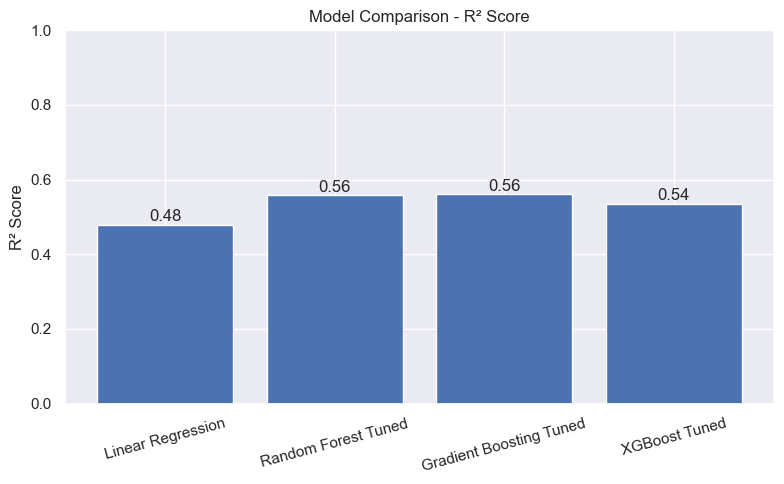

In [136]:
models = ['Linear Regression', 'Random Forest Tuned', 'Gradient Boosting Tuned', 'XGBoost Tuned']
r2_scores = [0.4788, 0.5576, 0.5605, 0.5352]

plt.figure(figsize=(8,5))
bars = plt.bar(models, r2_scores)

plt.title('Model Comparison - R² Score')
plt.ylabel('R² Score')
plt.ylim(0, 1)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f'{height:.2f}',
        ha='center'
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### FINAL MODEL
Based on the above testing performance, the Tuned Gradient Boosting Regressor was selected as the final model. </br>
This model achieved:
* Highest test R² score
* Lowest test RMSE
* Stable performance across train and test sets and
* Strong generalisation capability.

The final Gradient Boosting model was able to explain approximately 56% of the variance in the warehouse product movement while maintaining stable prediction performance on unseen data. The model effectively captured non-linear relationships and operational interactions among supply chain variables, making it suitable for predictive decision-making in warehouse and logistics management.


#### Observed vs Predicted Values (Best Model - Gradient Boost and Tuned Gradient Boosting model)

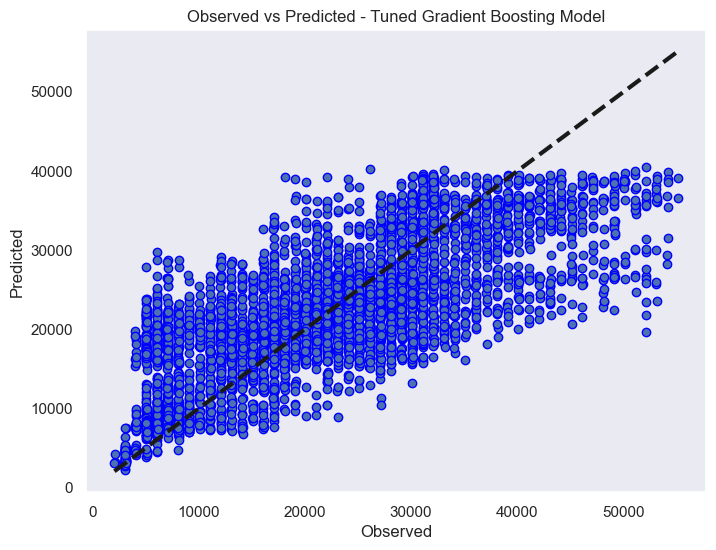

In [130]:
fig, ax = plt.subplots(figsize=(8, 6))
y_pred = gb_tuned.predict(X_test)
ax.scatter(y_test, y_pred, edgecolors=(0, 0, 1))
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=3)
ax.set_xlabel("Observed")
ax.set_ylabel("Predicted")
ax.set_title("Observed vs Predicted - Tuned Gradient Boosting Model")
plt.grid()
plt.show()

Observations:
* There is a clear positive trend between the observed and predicted values. Gradient Boosting model is able to capture the relationship between predictor variables and product weight.

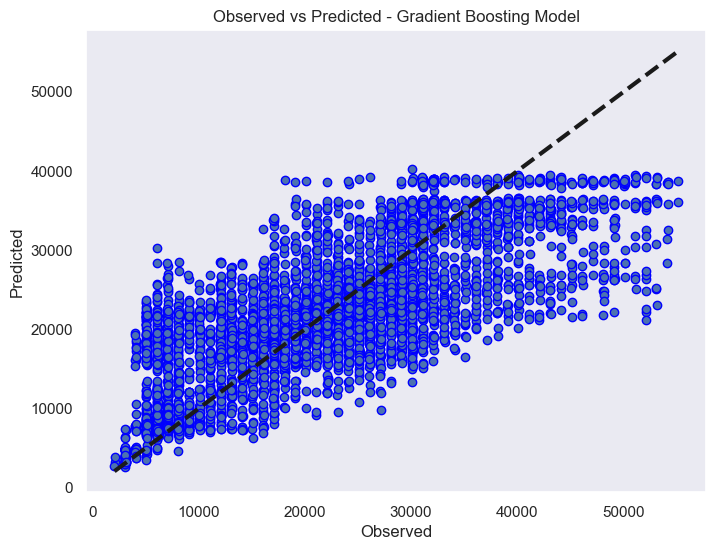

In [131]:
fig, ax = plt.subplots(figsize=(8, 6))
y_pred = gb.predict(X_test)
ax.scatter(y_test, y_pred, edgecolors=(0, 0, 1))
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=3)
ax.set_xlabel("Observed")
ax.set_ylabel("Predicted")
ax.set_title("Observed vs Predicted - Gradient Boosting Model")
plt.grid()
plt.show()

#### Feature importance (Gradient boost model)

In [132]:
print(
    pd.DataFrame(
        gb.feature_importances_, columns=["Imp"], index=X_train.columns
    ).sort_values(by="Imp", ascending=False)
)

                                      Imp
wh_age                           0.730995
wh_breakdown_l3m                 0.141457
transport_issue_l1y              0.034700
num_refill_req_l3m               0.033566
approved_wh_govt_certificate_A+  0.025294
wh_age_missing                   0.009156
approved_wh_govt_certificate_B+  0.005555
approved_wh_govt_certificate_B   0.005145
retail_shop_num                  0.002694
approved_wh_govt_certificate_C   0.002656
Location_type_Urban              0.001676
dist_from_hub                    0.001487
distributor_num                  0.001454
infra_score                      0.001239
workers_num                      0.001204
WH_regional_zone_Zone 3          0.000489
govt_check_l3m                   0.000413
Competitor_in_mkt                0.000217
flood_impacted                   0.000211
wh_owner_type_Rented             0.000154
WH_regional_zone_Zone 5          0.000103
zone_North                       0.000076
WH_regional_zone_Zone 6          0

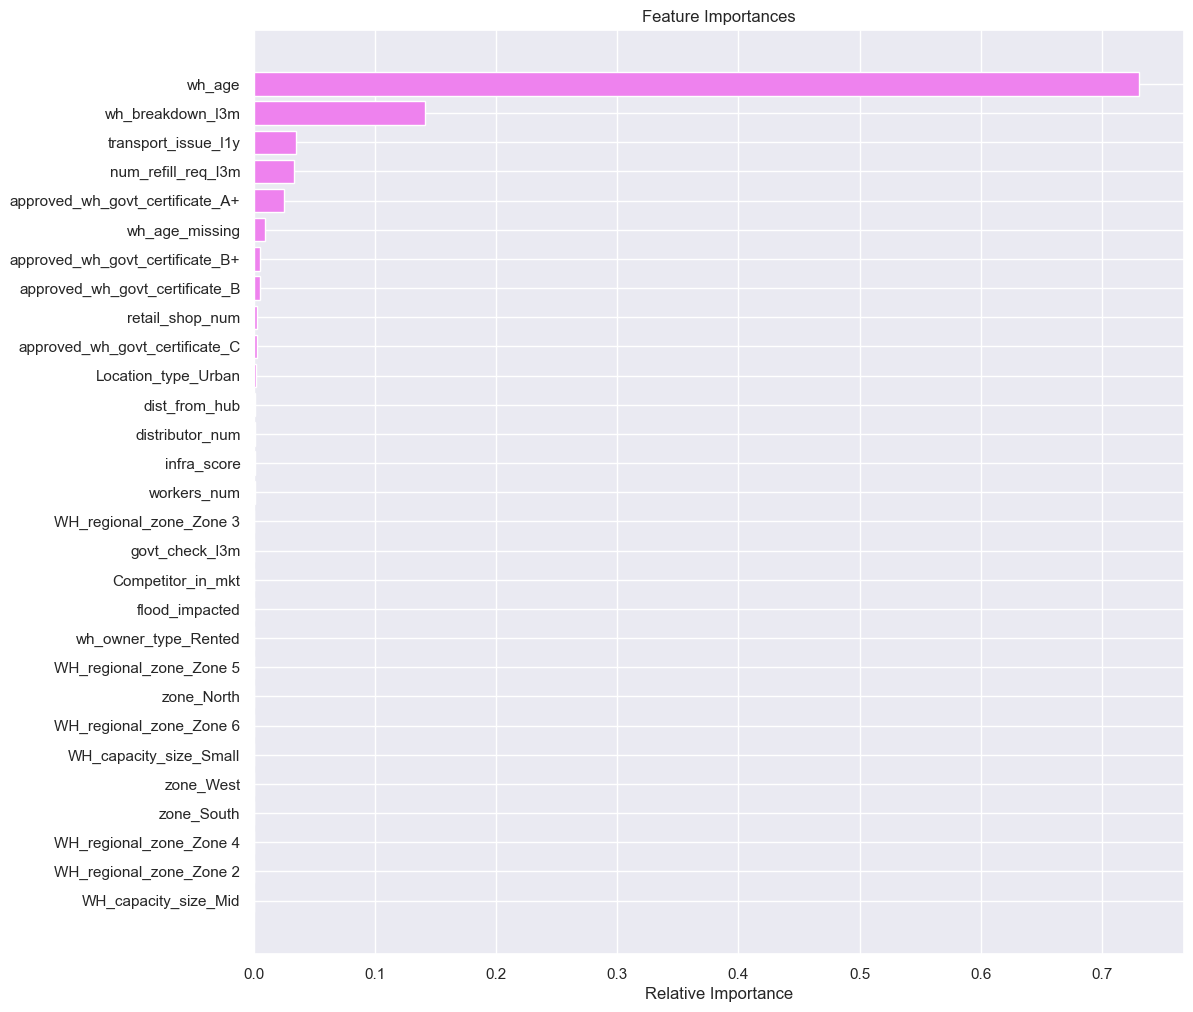

In [133]:
feature_names = X_train.columns
importances = gb.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

#### ACTIONABLE INSIGHTS AND RECOMMENDATIONS

#### Key Insights
* The variable ‘storage_issue_reported_l3m’ showed a very strong relationship with the target variable ‘product_wg_ton’. Warehouses reporting higher storage issues had higher product movement. This feature was later identified as a potential data leakage variable and removed from the baseline model.
* Warehouses with better infrastructure conditions like electric supply, flood proof facilities, temperature regulation systems showed better warehouse functioning and product handling.
* Warehouse capacity and workforce affected the product shipment. Larger warehouses with more workforce and greater distributor coverage handled larger product volumes.
* Geographical factors influenced the warehouse performance. Warehouses located farther from distributor hubs experienced lower operational efficiency due to transportation and delivery challenges.

#### Actionable business recommendations
* The company should invest in temperature regulation systems, backup power supply and flood proof mechanisms to improve the efficiency and reduce the disruptions.
* According to the numbers, the workforce doesn’t really affect the product movement. So, focus on productivity improvement by implementing training, using technology and automation.
* Increase storage capacity to accommodate growing product volumes and reduce storage related issues.
* Consider expanding warehouse capacity in high volume regions to reduce delivery times and improve customer service levels
* Lower certified warehouses can adopt best practices from highly certified warehouses to improve the quality standards, and overall performance.